In [ ]:
# script to compare the correlations of predictions across each prediction type #
# ie panel one - are we identifying the same functional variants by effect size #
# updates from V1 (archived):
# tabix filtered predictions are now from the correct BED file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
from scipy import stats
import numpy as np
import matplotlib
from tqdm import tqdm
import os
import pybedtools

In [2]:
# open the current DF for analyses, everything is already combined here
promoter_preds_df = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.tsv', sep = '\t')

In [3]:
# add mean mpac skew :/
promoter_preds_df.loc[:, 'mpac_mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max mpac skew
promoter_preds_df.loc[:, 'mpac_max_skew'] = [max([k,h,s], key=abs) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max parm skew
promoter_preds_df.loc[:, 'parm_max_skew'] = [max([k,h], key=abs) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add ID for merging wth phyloP scores
promoter_preds_df.loc[:, 'var_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]

In [4]:
# open phyloP annotated variants and add phyloP scores
phylo470 = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo470 = phylo470[phylo470[7] != '.']
# build dictionary for adding 
phylo470_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo470[0], 
                                                                                                 phylo470[1], 
                                                                                                 phylo470[3], 
                                                                                                 phylo470[4])],
                     [float(i.split('=')[-1]) for i in phylo470[7]]))
# add 470-way phyloP score
promoter_preds_df.loc[:, 'phyloP_470'] = [phylo470_dict.get(i) for i in promoter_preds_df['var_id']]

In [5]:
# add 241 way phyloP scores
phylo241 = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.241.mamm.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo241 = phylo241[phylo241[7] != '.']
# build dictionary for adding 
phylo241_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo241[0], 
                                                                                                 phylo241[1], 
                                                                                                 phylo241[3], 
                                                                                                 phylo241[4])],
                     [float(i.split('=')[-1]) for i in phylo241[7]]))
# add 241-way phyloP score
promoter_preds_df.loc[:, 'phyloP_241'] = [phylo241_dict.get(i) for i in promoter_preds_df['var_id']]

In [6]:
# first lets do all correlations at the nucleotide level
# some positions are NAs in promoterAI, we will drop those for this analysis
# we'll also drop those predictions without phyloP scores
# filter for those
promoterAI_filtered_preds = promoter_preds_df.dropna()
# drop multiple instances of the same variants in overlapping promoters
# break out the merge ID to a groupby ID for taking the mean of all three mutations at each position
promoterAI_filtered_preds.loc[:, 'groupby_id'] = [(':').join(i.split(':')[:2]) for i in promoterAI_filtered_preds['var_id']]
promoterAI_filtered_preds = promoterAI_filtered_preds.drop_duplicates(subset='var_id')

/tmp/ipykernel_3342320/3137119642.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promoterAI_filtered_preds.loc[:, 'groupby_id'] = [(':').join(i.split(':')[:2]) for i in promoterAI_filtered_preds['var_id']]


In [7]:
# check the overlap with updated exon bed files
# open exon bed file
exonBed = pybedtools.BedTool('../raw_data/archive2/gencode.v44.basic.annotation.exons.splice.autosomes.v2.bed')
# make a bed file from the predictions
promoterAI_filteredBED = pybedtools.BedTool.from_dataframe(
    pd.DataFrame({
        1 : promoterAI_filtered_preds['chrom'],
        2 : promoterAI_filtered_preds['pos'] - 1,
        3 : promoterAI_filtered_preds['pos'],
        4 : promoterAI_filtered_preds['id']
    })
)
# get the variants that intersect exons
exonIntersectVars = promoterAI_filteredBED.intersect(exonBed, wa=True).to_dataframe()

In [8]:
# filter intersecting variants
promoterAI_filtered_preds = promoterAI_filtered_preds[~promoterAI_filtered_preds['id'].isin(exonIntersectVars['name'].tolist())]

In [9]:
print(len(promoterAI_filtered_preds['gene_id'].unique()))

14048


In [10]:
len(promoterAI_filtered_preds)

9543105

In [11]:
# get the genes that are expressed in each cell type
k_expressed = list(promoterAI_filtered_preds[promoterAI_filtered_preds['k562_rna_tpm'] >= 1]['gene_id'].unique())
h_expressed = list(promoterAI_filtered_preds[promoterAI_filtered_preds['hepg2_rna_tpm'] >= 1]['gene_id'].unique())
s_expressed = list(promoterAI_filtered_preds[promoterAI_filtered_preds['sknsh_rna_tpm'] >= 1]['gene_id'].unique())
expressed_any = list(pd.Series(k_expressed + h_expressed + s_expressed).unique())

In [12]:
# compute correlations for each mpac skew prediction
# mpac vs. promoterAI
labels = []
labels_parm = []
proAI_corrs = []
parm_hepg2_corrs = []
parm_k562_corrs = []
parm_mean_corrs = []
parm_max_corrs = []
parm_proAI_corrs = []
# phyloP
# pearson
phylo_labels = []
phyloP_241_corrs = []
phyloP_470_corrs = []
# spearman
phylo_labels_spear = []
phyloP_241_corrs_spear = []
phyloP_470_corrs_spear = []
# compute correlations for promoterAI
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # update labels list
    labels.append(skew)
    # calculate correlation for that mpac column
    # promoterAI
    proAI_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['promoterAI_score'])[0], 2))
# compute correlations for k562_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_k562_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_k562_pred'])[0], 2))
# compute correlations for hepg2_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_hepg2_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_hepg2_pred'])[0], 2))
# compute correlations for mean_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_mean_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_mean_pred'])[0], 2))
# compute correlations for max_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_max_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_max_skew'])[0], 2))
# compute correlations for parm vs. promoterAI
for skew in ['parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew']:
    # update other label list
    labels_parm.append(skew)
    # calculate correlation for that parm column
    # promoterAI
    parm_proAI_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['promoterAI_score'])[0], 2))
# compute correlations for everything vs. 241-way phyloP
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels.append(skew)
    phyloP_241_corrs.append(round(stats.pearsonr(x=[abs(i) for i in promoterAI_filtered_preds[skew]], y=promoterAI_filtered_preds['phyloP_241'])[0], 2))
# compute correlations for everything vs. 470-way phyloP
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels.append(skew)
    phyloP_470_corrs.append(round(stats.pearsonr(x=[abs(i) for i in promoterAI_filtered_preds[skew]], y=promoterAI_filtered_preds['phyloP_470'])[0], 2))
# compute correlations for everything vs. 241-way phyloP
# spearman - stephen style
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels_spear.append(skew)
    phyloP_241_corrs_spear.append(round(stats.spearmanr(a=[abs(i) for i in promoterAI_filtered_preds[skew]], b=[max(0,i) for i in promoterAI_filtered_preds['phyloP_241']])[0], 2))
# compute correlations for everything vs. 470-way phyloP
# spearman - stephen style
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels_spear.append(skew)
    phyloP_470_corrs_spear.append(round(stats.spearmanr(a=[abs(i) for i in promoterAI_filtered_preds[skew]], b=[max(0,i) for i in promoterAI_filtered_preds['phyloP_470']])[0], 2))

/tmp/ipykernel_3342320/2609619102.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


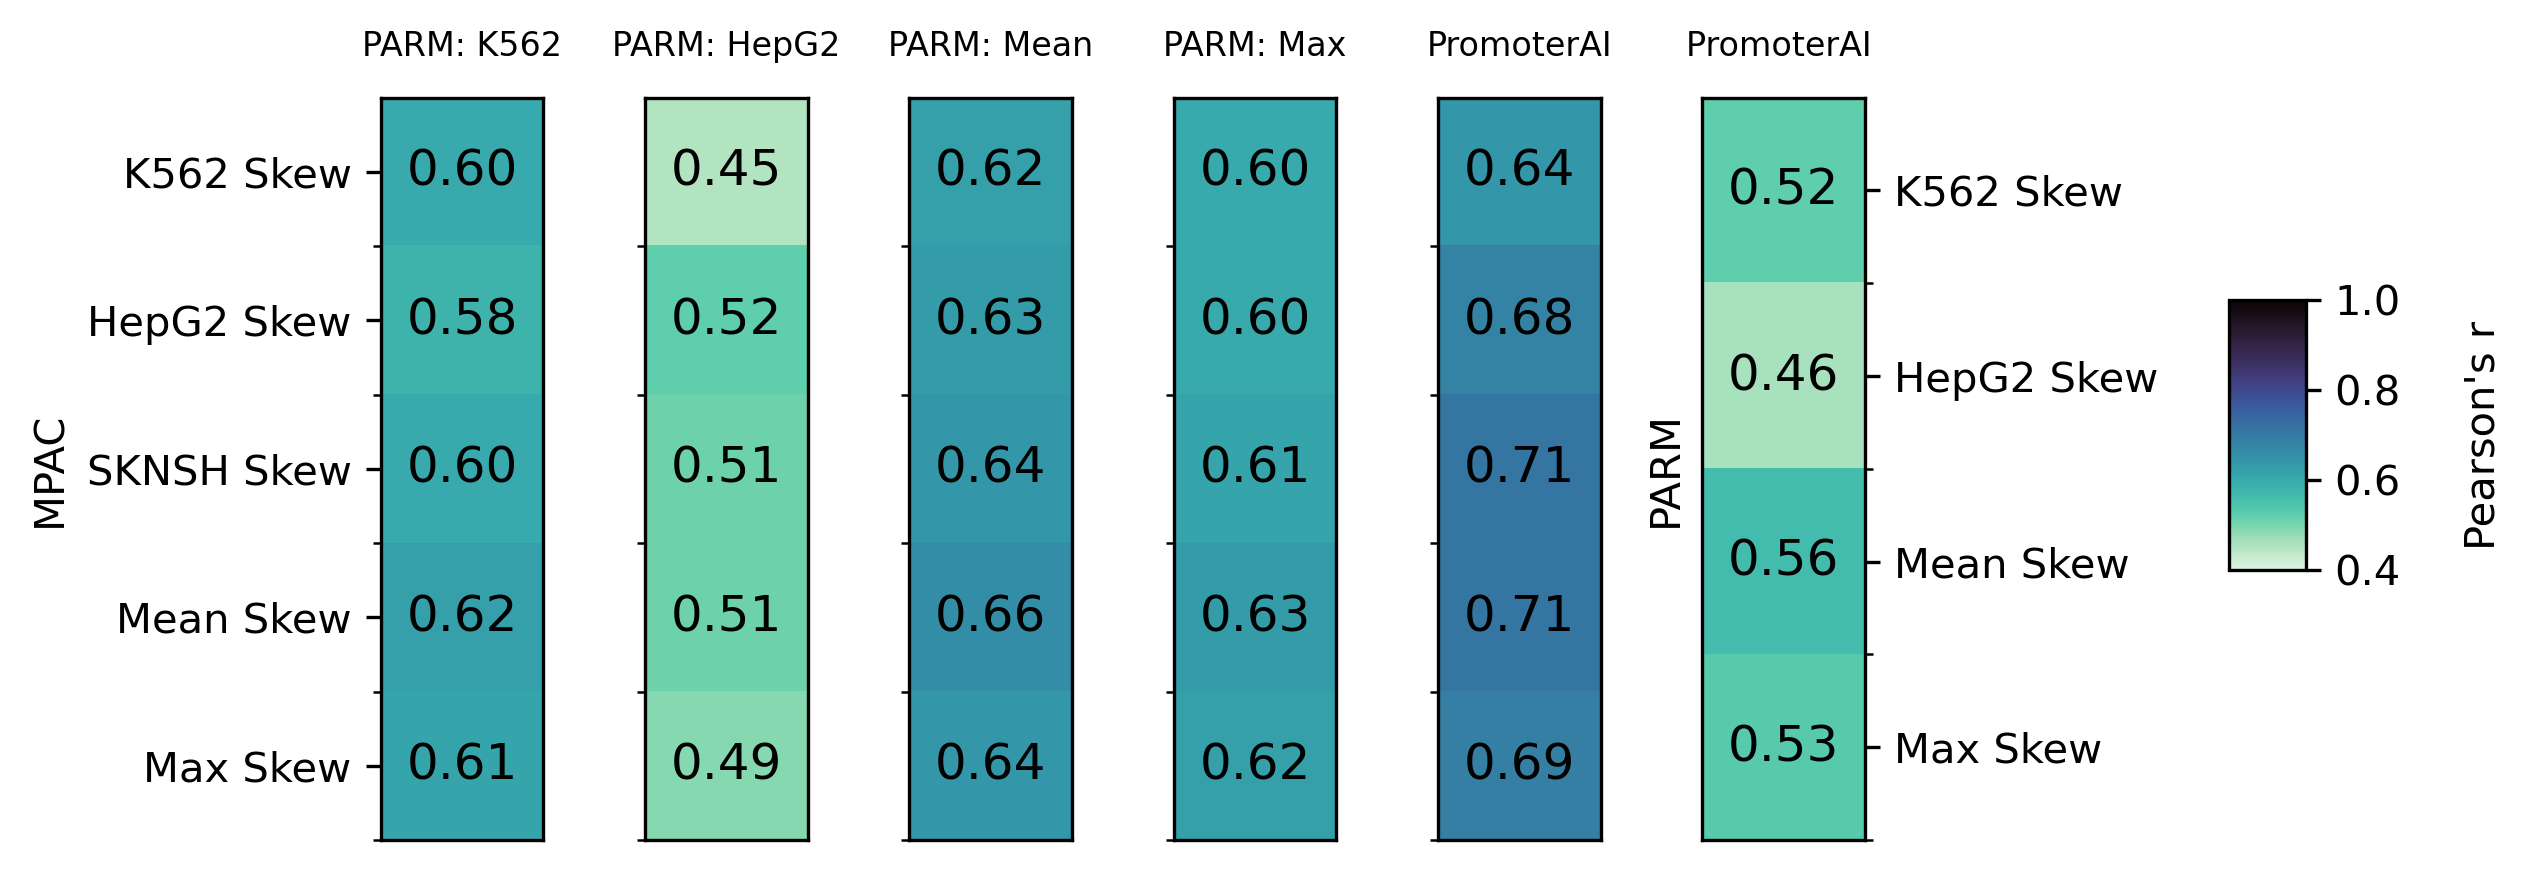

In [13]:
# Combine all data into a dictionary
labels = ['K562 Skew', 'HepG2 Skew', 'SKNSH Skew', 'Mean Skew', 'Max Skew']
labels_parm = ['K562 Skew', 'HepG2 Skew', 'Mean Skew', 'Max Skew']
data = {
    "PARM: K562": pd.Series(parm_k562_corrs, index=labels),
    "PARM: HepG2": pd.Series(parm_hepg2_corrs, index=labels),
    "PARM: Mean": pd.Series(parm_mean_corrs, index=labels),
    "PARM: Max" : pd.Series(parm_max_corrs, index=labels),
    "PromoterAI": pd.Series(proAI_corrs, index=labels),
    "PromoterAI ": pd.Series(parm_proAI_corrs, index=labels_parm)
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 6, figsize=(8.5, 3), dpi=300)

cmap = 'mako_r'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=8, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('MPAC', fontsize=10)
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)

for i in range(1, 5):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

axes[5].set_yticks(np.arange(len(labels_parm)))
axes[5].set_yticklabels(labels_parm, fontsize=10)
axes[5].yaxis.tick_right() # Move labels to the right for clarity
axes[5].set_yticks(np.arange(len(labels_parm)) + 0.5, minor=True)
axes[5].set_ylabel('PARM', size=10)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Pearson's r", fontsize=10, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
#plt.savefig('mpac_parm_promoterAI_promoter_prediction_correlations_heatmap.pdf')
plt.show()

In [14]:
lenPreds = len(promoterAI_filtered_preds)
# calculate the concordance rate of predictions
# mpac v proAI
# k562
k_mpac_proAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# hepg2
h_mpac_proAI_conc = pd.Series([1 if h > 0 and p > 0 or h < 0 and p < 0 else 0 for h, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# sknsh
s_mpac_proAI_conc = pd.Series([1 if s > 0 and p > 0 or s < 0 and p < 0 else 0 for s, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mean
mean_mpac_proAI_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# max
max_mpac_proAI_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mpac v PARM: K562
# k562
k_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# max
max_mpac_parm_k_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# mpac v PARM: HepG2
# k562
k_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# max
max_mpac_parm_h_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# mpac v PARM: Mean
# k562
k_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# max
max_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# mpac v PARM: Max
# k562
k_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# hepg2
h_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# sknsh
s_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# mean
mean_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# max
max_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# PARM vs. promoterAI
# k562
k_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_k562_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# hepg2
h_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_hepg2_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mean
mean_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_mean_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# max
max_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_max_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds

/tmp/ipykernel_3342320/1125966321.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


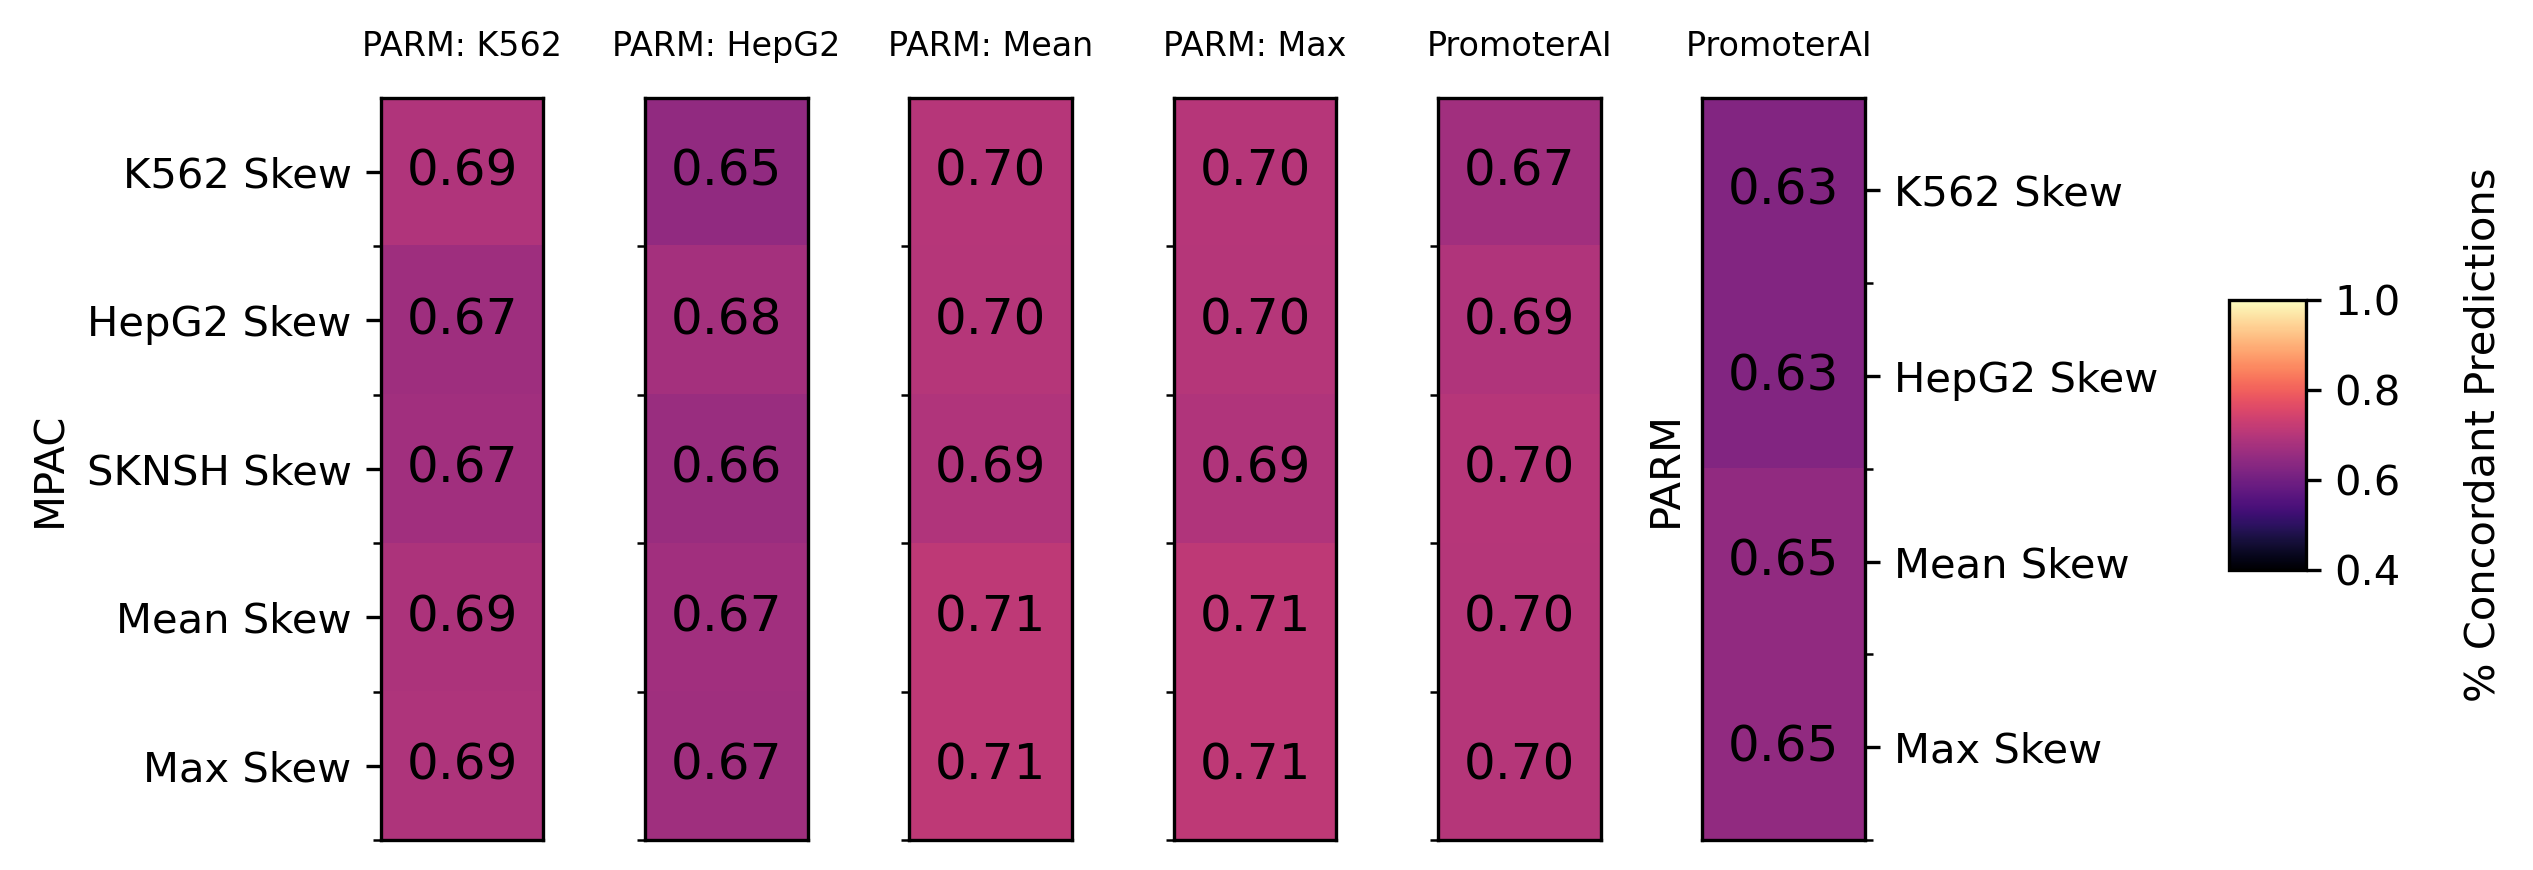

In [15]:
labels = ['K562 Skew', 'HepG2 Skew', 'SKNSH Skew', 'Mean Skew', 'Max Skew']
labels_parm = ['K562 Skew', 'HepG2 Skew', 'Mean Skew', 'Max Skew']
data = {
    "PARM: K562": pd.Series([k_mpac_parm_k_conc, h_mpac_parm_k_conc, s_mpac_parm_k_conc, mean_mpac_parm_k_conc, max_mpac_parm_k_conc], index=labels),
    "PARM: HepG2": pd.Series([k_mpac_parm_h_conc, h_mpac_parm_h_conc, s_mpac_parm_h_conc, mean_mpac_parm_h_conc, max_mpac_parm_h_conc], index=labels),
    "PARM: Mean": pd.Series([k_mpac_parm_mean_conc, h_mpac_parm_mean_conc, s_mpac_parm_mean_conc, mean_mpac_parm_mean_conc, max_mpac_parm_mean_conc], index=labels),
    "PARM: Max" : pd.Series([k_mpac_parm_max_conc, h_mpac_parm_max_conc, s_mpac_parm_max_conc, mean_mpac_parm_max_conc, max_mpac_parm_max_conc], index=labels),
    "PromoterAI": pd.Series([k_mpac_proAI_conc, h_mpac_proAI_conc, s_mpac_proAI_conc, mean_mpac_proAI_conc, max_mpac_proAI_conc], index=labels),
    "PromoterAI ": pd.Series([k_parm_pAI_conc, h_parm_pAI_conc, mean_parm_pAI_conc, max_parm_pAI_conc], index=labels_parm)
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 6, figsize=(8.5, 3), dpi=300)

cmap = 'magma'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=8, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)
axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('MPAC', fontsize=10)
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
for i in range(1, 5):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

axes[5].set_yticks(np.arange(len(labels_parm)))
axes[5].set_yticklabels(labels_parm, fontsize=10)
axes[5].yaxis.tick_right() # Move labels to the right for clarity
axes[5].set_yticks(np.arange(len(labels_parm)) + 0.5, minor=True)
axes[5].set_ylabel('PARM', size=10)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("% Concordant Predictions", fontsize=10, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
#plt.savefig('mpac_parm_promoterAI_promoter_prediction_concordance_heatmap.pdf')
plt.show()

In [16]:
mean_mpac_proAI_conc

np.float64(0.6997869142171232)

In [17]:
# get the percentile of an absolute skew of 0.5 for calling promoterAI and PARM emVars
mpac_emvar_quantile = stats.percentileofscore([abs(i) for i in promoterAI_filtered_preds['mpac_mean_skew']], .5) / 100
print(mpac_emvar_quantile)
# get the absolute skew thresholds for each prediction method
# promoterAI
proAI_emVar_thresh = np.quantile([abs(i) for i in promoterAI_filtered_preds['promoterAI_score']], mpac_emvar_quantile)
print(proAI_emVar_thresh)
# PARM
PARM_emVar_thresh = np.quantile([abs(i) for i in promoterAI_filtered_preds['parm_mean_pred']], mpac_emvar_quantile)
print(PARM_emVar_thresh)

0.9409069689582163


0.301
0.12756160073866288


In [18]:
# break out the merge ID to a groupby ID for taking the mean of all three mutations at each position
promoterAI_filtered_preds.loc[:, 'groupby_id'] = [(':').join(i.split(':')[:2]) for i in promoterAI_filtered_preds['var_id']]
# groupby mean
proAI_filtered_mean_groupby = promoterAI_filtered_preds.filter(['groupby_id', 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew',
                                                                'parm_hepg2_pred', 'parm_k562_pred', 'parm_mean_pred', 'parm_max_skew',
                                                                'promoterAI_score', 'phyloP_470', 'phyloP_241']).groupby('groupby_id').mean().reset_index()

In [19]:
# call emVars for each MPAC cell type, parm cell type, means, and promoterAI
### MPAC ###
# k562
proAI_filtered_mean_groupby.loc[:,'mpac_k562_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['k562_skew_pred']]
# hepg2
proAI_filtered_mean_groupby.loc[:,'mpac_hepg2_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['hepg2_skew_pred']]
# sknsh
proAI_filtered_mean_groupby.loc[:,'mpac_sknsh_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['sknsh_skew_pred']]
# mean
proAI_filtered_mean_groupby.loc[:,'mpac_mean_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['mpac_mean_skew']]
# max
proAI_filtered_mean_groupby.loc[:,'mpac_max_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['mpac_max_skew']]
### PARM ###
# k562
proAI_filtered_mean_groupby.loc[:, 'parm_k562_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_k562_pred']]
# hepg2
proAI_filtered_mean_groupby.loc[:, 'parm_hepg2_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_hepg2_pred']]
# mean
proAI_filtered_mean_groupby.loc[:, 'parm_mean_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_mean_pred']]
# max
proAI_filtered_mean_groupby.loc[:, 'parm_max_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_max_skew']]
### promterAI ###
proAI_filtered_mean_groupby.loc[:, 'promoterAI_emVar'] = [1 if abs(i) > proAI_emVar_thresh else 0 for i in proAI_filtered_mean_groupby['promoterAI_score']]

In [20]:
proAI_filtered_mean_groupby.head()

,groupby_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,mpac_mean_skew,mpac_max_skew,parm_hepg2_pred,parm_k562_pred,parm_mean_pred,parm_max_skew,...,mpac_k562_emVar,mpac_hepg2_emVar,mpac_sknsh_emVar,mpac_mean_emVar,mpac_max_emVar,parm_k562_emVar,parm_hepg2_emVar,parm_mean_emVar,parm_max_emVar,promoterAI_emVar
0,chr10:100009948,-0.765596,-0.489724,-0.539004,-0.598108,-0.765596,-0.057361,-0.033407,-0.045384,-0.057361,...,1,0,1,1,1,0,0,0,0,0
1,chr10:100009949,-0.679008,-0.300394,-0.275782,-0.418395,-0.444360,-0.033512,-0.027542,-0.030527,-0.032488,...,1,0,0,0,0,0,0,0,0,0
2,chr10:100009950,-0.505355,-0.210674,-0.147546,-0.287858,-0.465650,-0.039495,-0.045833,-0.042664,-0.050866,...,1,0,0,0,0,0,0,0,0,0
3,chr10:100009951,-1.013073,-0.626431,-0.690968,-0.776824,-1.013073,-0.073669,-0.051701,-0.062685,-0.074114,...,1,1,1,1,1,0,0,0,0,1
4,chr10:100009952,-0.847363,-0.556447,-0.634124,-0.679311,-0.847363,-0.046782,-0.051726,-0.049254,-0.054256,...,1,1,1,1,1,0,0,0,0,1


In [21]:
def calculate_emvar_rates(preds,
                          list_of_phylo_bins,
                          phylo_col,
                          pred_col,
                          emvar_col,
                          model_name):
    """
    Returns a dataframe of emVar rates by phyloP bin, ready for plotting.
    """
    # 1. Prepare Data
    df = preds.copy()
    
    # # Create unique ID (chrom:pos)
    # df['chrom_pos'] = df['var_id'].apply(lambda x: ':'.join(x.split(':')[:2]))
    
    # # Deduplicate: take max to resolve duplicates at same position
    # df = df.groupby('chrom_pos')[[phylo_col, pred_col, emvar_col]].max().reset_index()

    # 2. Split into Pos/Neg Skew groups
    over_expr = df[df[pred_col] >= 0].copy()
    under_expr = df[df[pred_col] < 0].copy()
    
    # (Optional) Calculate Global Means if you need them for dashed lines later
    # You could return these as a dictionary if needed, but we'll skip for the DF focus
    
    # 3. Binning Helper
    def get_binned_data(sub_df, label):
        sub_df['bin'] = pd.cut(sub_df[phylo_col], bins=list_of_phylo_bins)
        
        # Calculate mean (rate) and count
        agg = sub_df.groupby('bin', observed=False)[emvar_col].agg(['mean', 'count']).reset_index()

        # Format for plotting
        agg['phylo_mid'] = agg['bin'].apply(lambda x: x.mid).astype(float)
        agg['rate_pct'] = agg['mean'] * 100
        agg['group'] = label
        return agg

    # 4. Calculate and Combine
    over_agg = get_binned_data(over_expr, 'over-expr')
    under_agg = get_binned_data(under_expr, 'under-expr')
    
    # Combine internal groups (over vs under)
    result_df = pd.concat([over_agg, under_agg], ignore_index=True)
    
    # 5. Add the Model Name
    result_df['Prediction'] = model_name
    
    return result_df

In [22]:
# get phyloP bins
bins470 = range(int(promoterAI_filtered_preds['phyloP_470'].min()), int(promoterAI_filtered_preds['phyloP_470'].max()) + 1)
bins241 = range(int(promoterAI_filtered_preds['phyloP_241'].min()), int(promoterAI_filtered_preds['phyloP_241'].max()) + 1)

In [23]:
# calculate MPAC rate Mean
df_mpac_mean = calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='mpac_mean_skew',
    emvar_col='mpac_mean_emVar',
    model_name='MPAC Mean'
)
# calculate promoterAI rate
df_pAI= calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='promoterAI_score',
    emvar_col='promoterAI_emVar',
    model_name='PromoterAI'
)
# calculate PARM rate
df_PARM= calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='parm_mean_pred',
    emvar_col='parm_mean_emVar',
    model_name='PARM Mean'
)

In [24]:
# calculate mean mutation rate for each method
# MPAC
mpac_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] >= 0]['mpac_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_max_skew'] >= 0])) * 100
mpac_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] < 0]['mpac_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] >= 0])) * 100
# PARM
parm_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] >= 0]['parm_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_max_skew'] >= 0])) * 100
parm_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] < 0]['parm_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] >= 0])) * 100
# promoterAI
pAI_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0]['promoterAI_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0])) * 100
pAI_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] < 0]['promoterAI_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0])) * 100

In [25]:
mpac_over_mean

np.float64(1.3135718650090809)

In [26]:
parm_over_mean

np.float64(3.476806855871363)

In [27]:
# convert the percent hits to a ratio for each 
# mpac
df_mpac_mean.loc[:,'hit_ratio'] = [i / mpac_over_mean if j == 'over-expr' else i / mpac_under_mean for i, j in zip(df_mpac_mean['rate_pct'], df_mpac_mean['group'])]
# parm
df_PARM.loc[:,'hit_ratio'] = [i / parm_over_mean if j == 'over-expr' else i / parm_under_mean for i, j in zip(df_PARM['rate_pct'], df_PARM['group'])]
# promoterAI
df_pAI.loc[:,'hit_ratio'] = [i / pAI_over_mean if j == 'over-expr' else i / pAI_under_mean for i, j in zip(df_pAI['rate_pct'], df_pAI['group'])]

In [28]:
final_plot_df = pd.concat([df_mpac_mean, df_pAI, df_PARM], ignore_index=True)

In [29]:
final_plot_df.head()

,bin,mean,count,phylo_mid,rate_pct,group,Prediction,hit_ratio
0,"(-20, -19]",NaN,0,-19.5,NaN,over-expr,MPAC Mean,NaN
1,"(-19, -18]",NaN,0,-18.5,NaN,over-expr,MPAC Mean,NaN
2,"(-18, -17]",NaN,0,-17.5,NaN,over-expr,MPAC Mean,NaN
3,"(-17, -16]",NaN,0,-16.5,NaN,over-expr,MPAC Mean,NaN
4,"(-16, -15]",0.007605,789,-15.5,0.760456,over-expr,MPAC Mean,0.578922


In [30]:
# define a palette for each prediction type
palette = {
    'MPAC Mean' : 'midnightblue',
    'PromoterAI' : 'firebrick',
    'PARM Mean' : 'darkmagenta'
}

Text(0.0, 1.0, '')

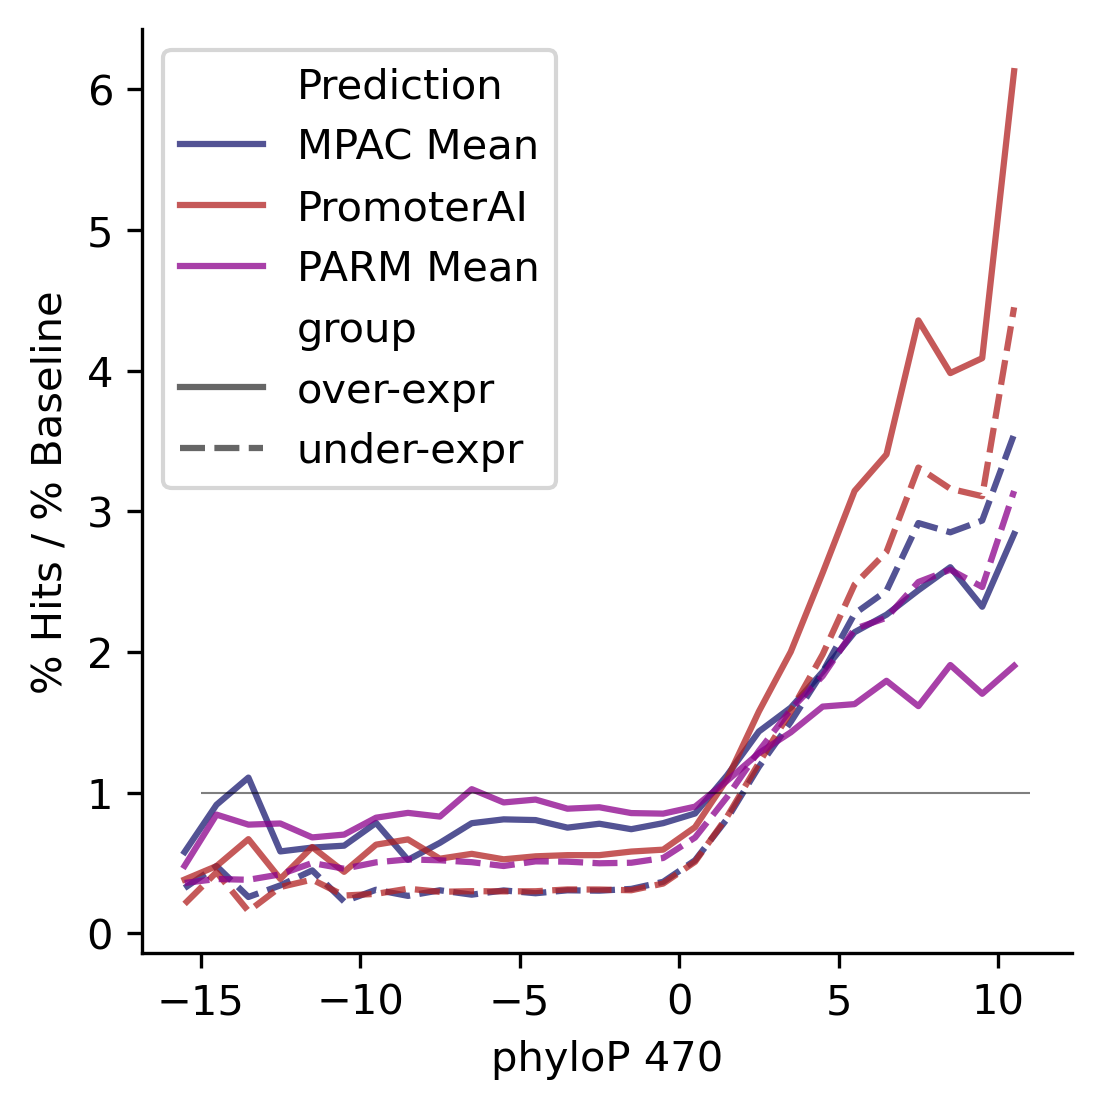

In [36]:
plt.figure(figsize=(4, 4), dpi=300)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sns.lineplot(
    data=final_plot_df,
    x='phylo_mid',
    y='hit_ratio',
    hue='Prediction',        # Color by Over/Under
    style='group', # Dash/Solid by Model
    palette=palette,
    linewidth=1.5,
    alpha=0.75
)
plt.xlabel('phyloP 470')
plt.ylabel('% Hits / % Baseline')
plt.hlines(y=1, xmin=-15, xmax=max(bins470), color='k', linestyles='solid', alpha=0.5, linewidth=0.5)
sns.despine()
plt.title('', loc = 'left')
#plt.savefig('../plots/percent_hits_by_phylop_mean_470.pdf')

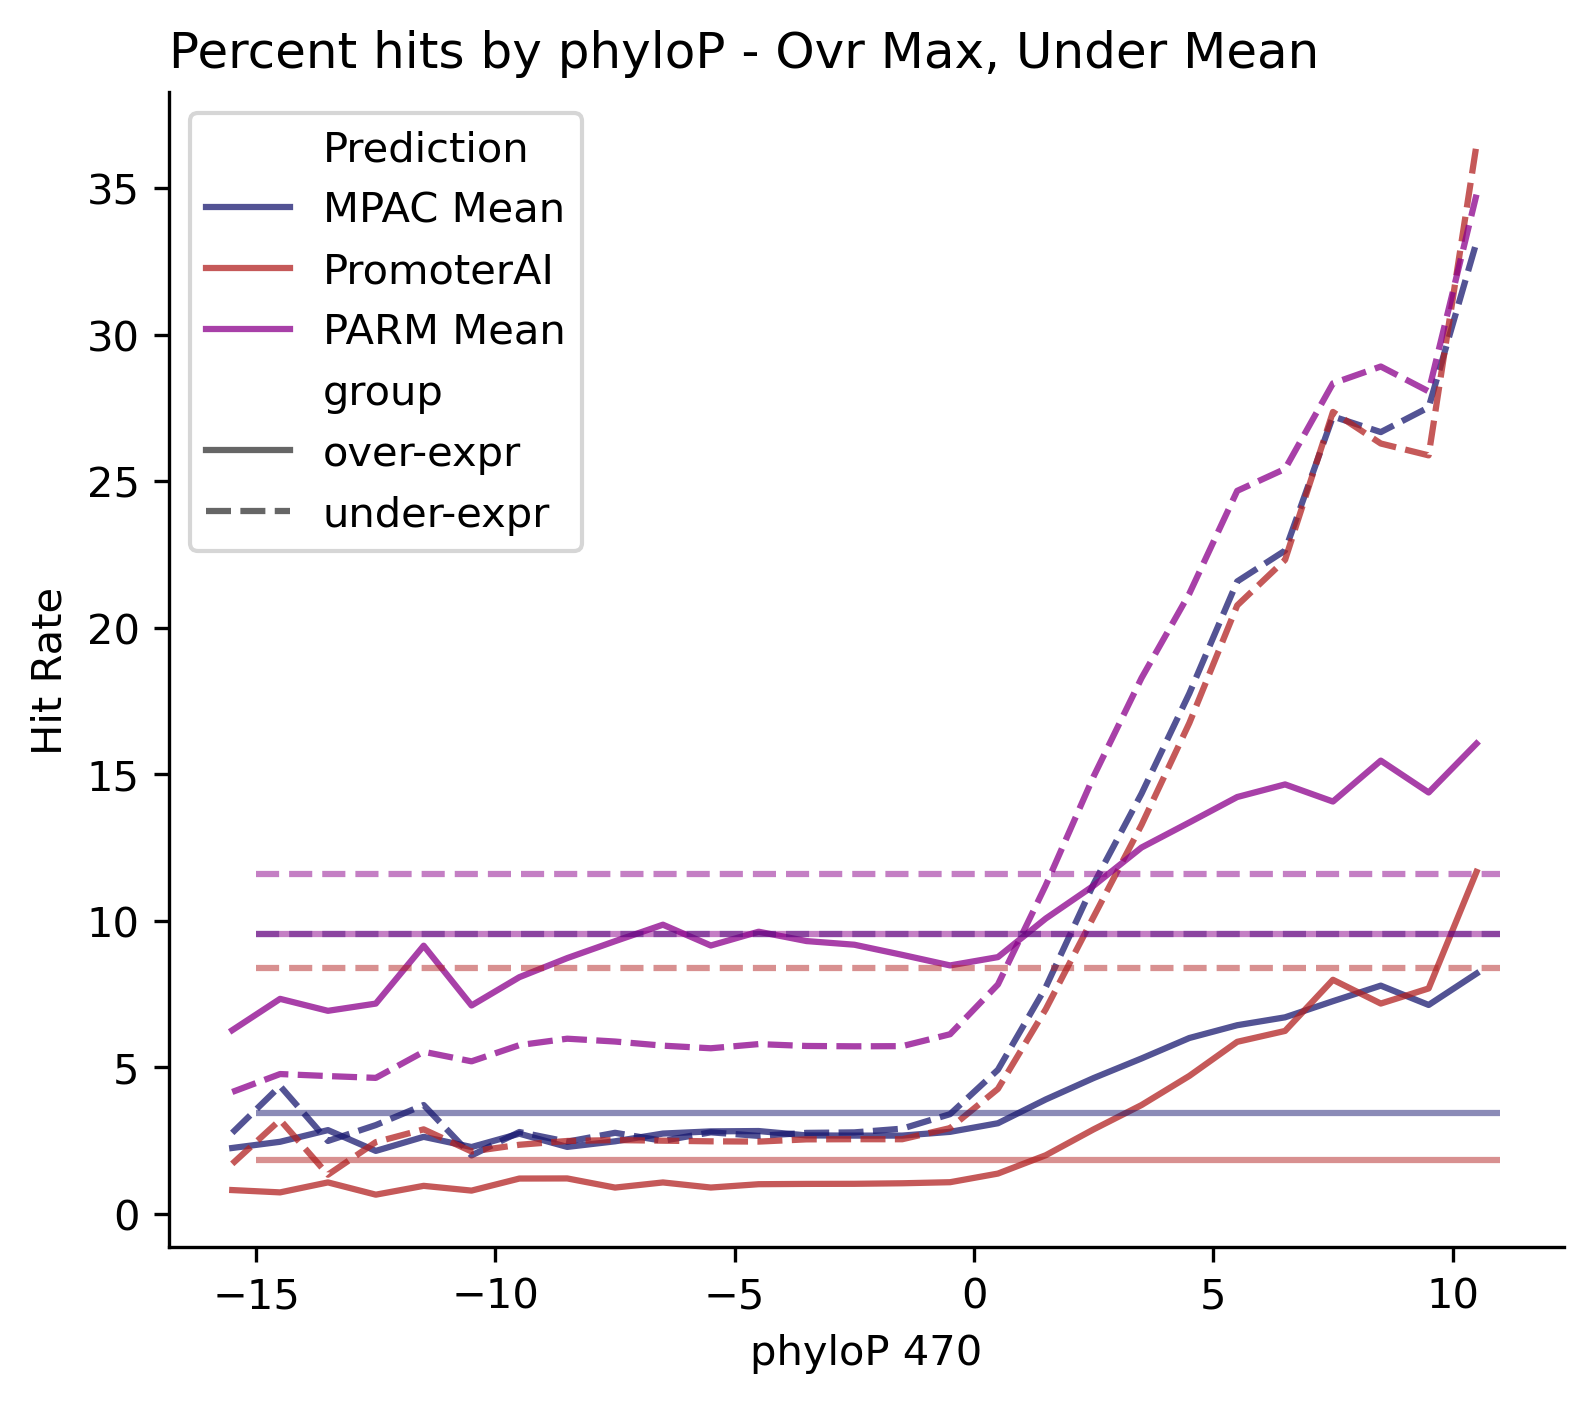

In [ ]:
plt.figure(figsize=(6, 5), dpi=300)

sns.lineplot(
    data=final_plot_df_ovrMAX,
    x='phylo_mid',
    y='rate_pct',
    hue='Prediction',        # Color by Over/Under
    style='group', # Dash/Solid by Model
    palette=palette,
    linewidth=1.5,
    alpha=0.75
)
plt.xlabel('phyloP 470')
plt.ylabel('Hit Rate')
plt.hlines(y=mpac_over_mean, xmin=-15, xmax=max(bins470), color='midnightblue', linestyles='solid', alpha=0.5, linewidth=1.5)
plt.hlines(y=mpac_under_mean, xmin=-15, xmax=max(bins470), color='midnightblue', linestyles='dashed', alpha=0.5, linewidth=1.5)
plt.hlines(y=parm_over_mean, xmin=-15, xmax=max(bins470), color='darkmagenta', linestyles='solid', alpha=0.5, linewidth=1.5)
plt.hlines(y=parm_under_mean, xmin=-15, xmax=max(bins470), color='darkmagenta', linestyles='dashed', alpha=0.5, linewidth=1.5)
plt.hlines(y=pAI_over_mean, xmin=-15, xmax=max(bins470), color='firebrick', linestyles='solid', alpha=0.5, linewidth=1.5)
plt.hlines(y=pAI_under_mean, xmin=-15, xmax=max(bins470), color='firebrick', linestyles='dashed', alpha=0.5, linewidth=1.5)
sns.despine()
plt.title('Percent hits by phyloP - Ovr Max, Under Mean', loc = 'left')
plt.show()

In [ ]:
promoterAI_filtered_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,parm_hepg2_emVar,parm_emVar_any,mpac_mean_skew,mpac_max_skew,parm_max_skew,var_id,phyloP_470,phyloP_241,groupby_id,is_positive
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,...,0,0,-0.000599,0.014021,0.002983,chr1:65169:A:C,2.679,1.880,chr1:65169,False
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,...,0,0,-0.006068,-0.019000,0.004086,chr1:65169:A:G,2.679,1.880,chr1:65169,False
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,...,0,0,-0.021297,-0.028004,-0.001701,chr1:65169:A:T,2.679,1.880,chr1:65169,False
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,...,0,0,0.071461,0.101806,0.000730,chr1:65170:G:A,-0.117,-0.263,chr1:65170,True
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,C,0.287499,0.300818,0.013319,0.352586,0.341317,...,0,0,-0.010420,-0.033308,0.000470,chr1:65170:G:C,-0.117,-0.263,chr1:65170,False


In [59]:
# make a dictionary with the groupby_id as a key and the mean skew as a value
mpac_mean_groupby_dict = dict(zip(proAI_filtered_mean_groupby['groupby_id'], proAI_filtered_mean_groupby['mpac_mean_skew']))
mpac_max_groupby_dict = dict(zip(proAI_filtered_mean_groupby['groupby_id'], proAI_filtered_mean_groupby['mpac_max_skew']))
# proAI_filtered_mean_groupby.head()

In [60]:
# Create boolean column first
promoterAI_filtered_preds['is_positive'] = promoterAI_filtered_preds['mpac_mean_skew'] >= 0

# Then use value_counts which is highly optimized
skew_dir_count = (promoterAI_filtered_preds.groupby('groupby_id')['is_positive']
                  .value_counts()
                  .unstack(fill_value=0))

# Rename columns
skew_dir_count.columns = ['negative', 'positive']

In [61]:
# add directionality information to the variant by mean and max
skew_dir_count.loc[:, 'mean_skew_dir'] = ['positive' if mpac_mean_groupby_dict.get(i) >= 0 else 'negative' for i in skew_dir_count.index]
skew_dir_count.loc[:, 'max_skew_dir'] = ['positive' if mpac_max_groupby_dict.get(i) >= 0 else 'negative' for i in skew_dir_count.index]
# add a categorical label to groupby df
skews_labels = []
for i in skew_dir_count['negative'].tolist():
    if i == 3:
        skews_labels.append('all neg')
    elif i == 2:
        skews_labels.append('2 neg, 1 pos')
    elif i == 1:
        skews_labels.append('1 neg, 2 pos')
    else:
        skews_labels.append('all pos')
skew_dir_count.loc[:,'skews_label'] = skews_labels

In [62]:
promoterAI_filtered_preds.groupby('groupby_id').size().value_counts()

3    3844895
Name: count, dtype: int64

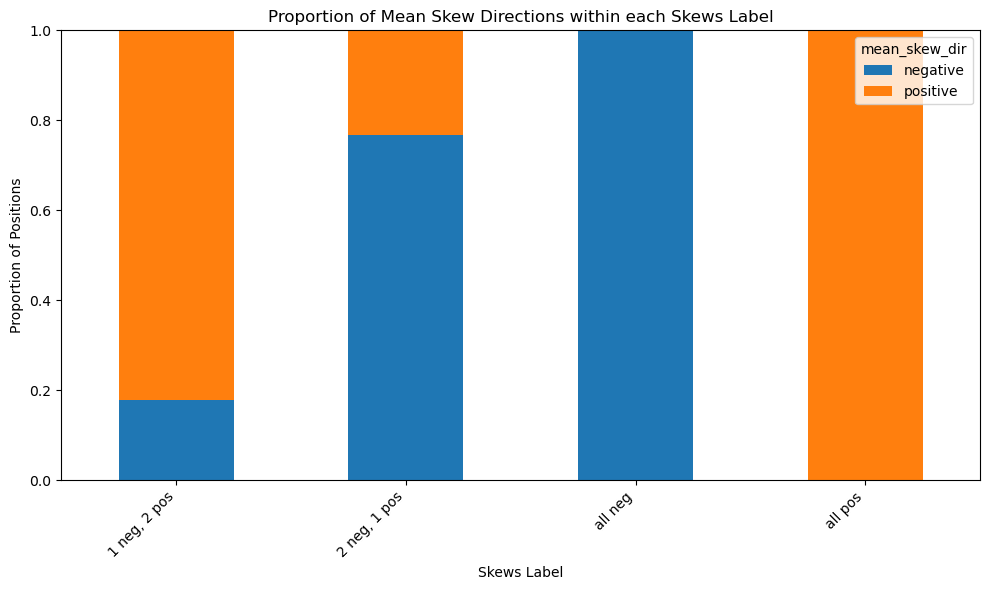

In [63]:
# Group and count positions (rows) in each category
grouped_counts = skew_dir_count.groupby(['skews_label', 'mean_skew_dir']).size().unstack(fill_value=0)

# Convert to proportions within each skews_label
grouped_props = grouped_counts.div(grouped_counts.sum(axis=1), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
grouped_props.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Skews Label')
ax.set_ylabel('Proportion of Positions')
ax.set_title('Proportion of Mean Skew Directions within each Skews Label')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

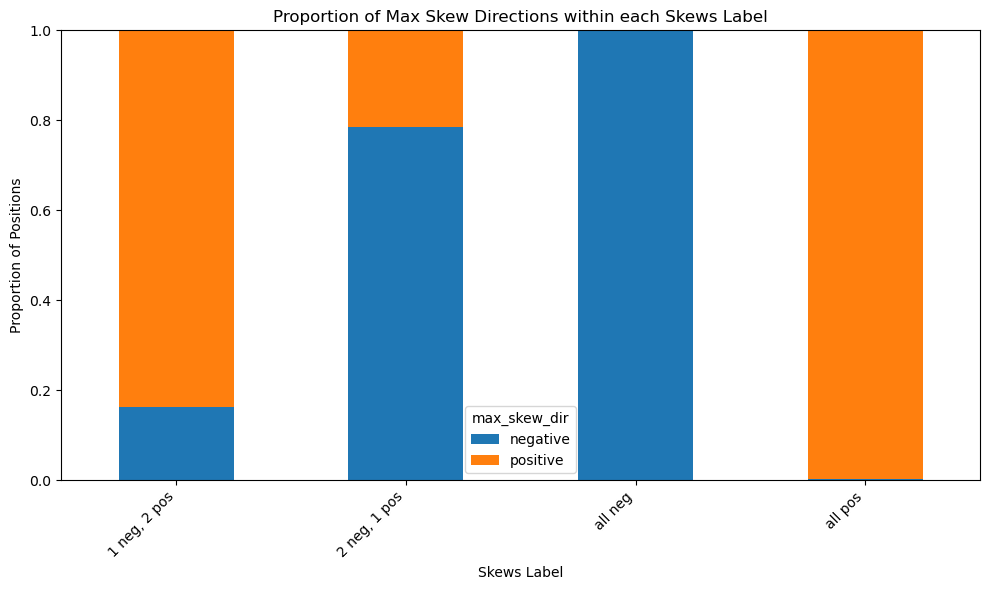

In [64]:
# Group and count positions (rows) in each category
grouped_counts = skew_dir_count.groupby(['skews_label', 'max_skew_dir']).size().unstack(fill_value=0)

# Convert to proportions within each skews_label
grouped_props = grouped_counts.div(grouped_counts.sum(axis=1), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
grouped_props.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Skews Label')
ax.set_ylabel('Proportion of Positions')
ax.set_title('Proportion of Max Skew Directions within each Skews Label')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

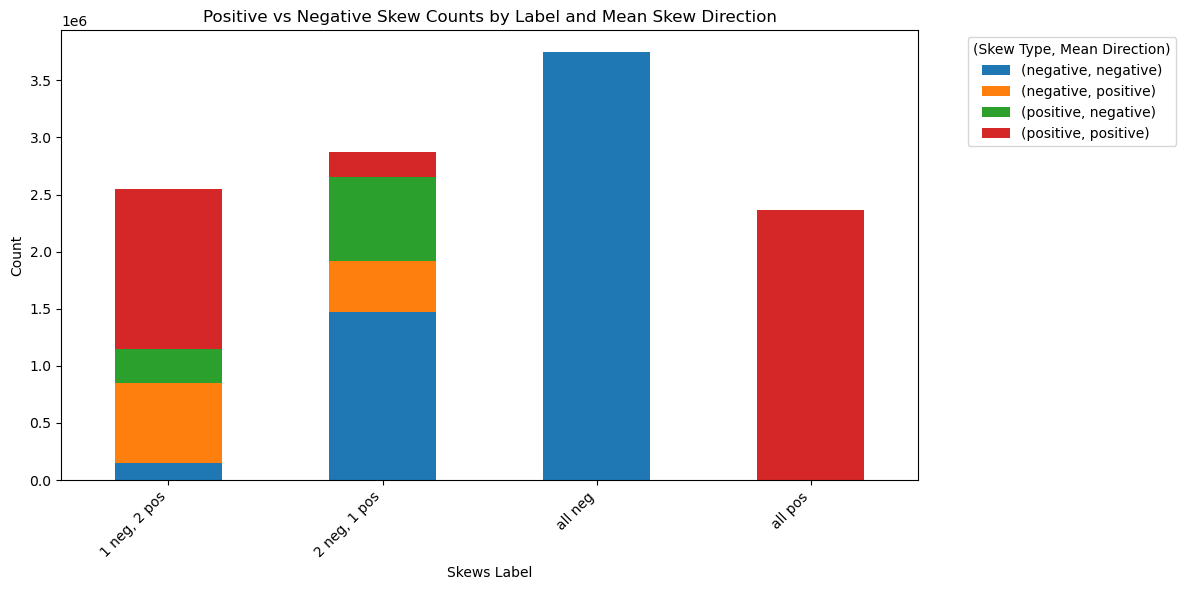

In [ ]:
import matplotlib.pyplot as plt

# Group by both skews_label and mean_skew_dir, sum the counts
grouped = skew_dir_count.groupby(['skews_label', 'mean_skew_dir'])[['negative', 'positive']].sum()

# Unstack to get mean_skew_dir as columns for side-by-side bars
grouped_unstacked = grouped.unstack(level='mean_skew_dir')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
grouped_unstacked.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Skews Label')
ax.set_ylabel('Count')
ax.set_title('Positive vs Negative Skew Counts by Label and Mean Skew Direction')
ax.legend(title='(Skew Type, Mean Direction)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

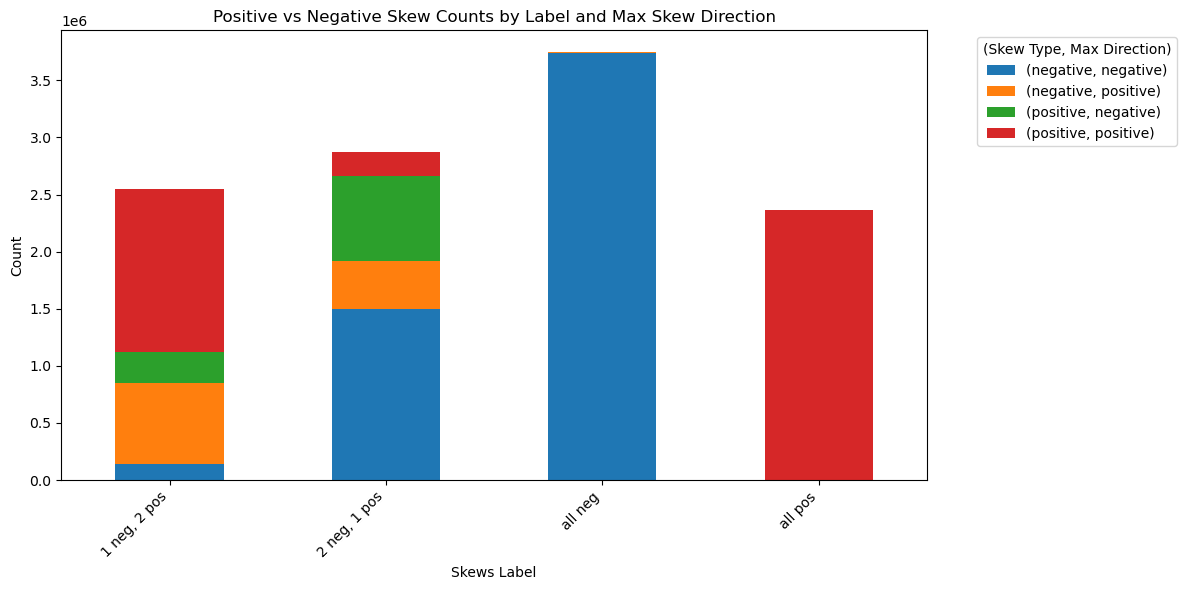

In [ ]:
import matplotlib.pyplot as plt

# Group by both skews_label and mean_skew_dir, sum the counts
grouped = skew_dir_count.groupby(['skews_label', 'max_skew_dir'])[['negative', 'positive']].sum()

# Unstack to get mean_skew_dir as columns for side-by-side bars
grouped_unstacked = grouped.unstack(level='max_skew_dir')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
grouped_unstacked.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Skews Label')
ax.set_ylabel('Count')
ax.set_title('Positive vs Negative Skew Counts by Label and Max Skew Direction')
ax.legend(title='(Skew Type, Max Direction)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3526369/3132810141.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


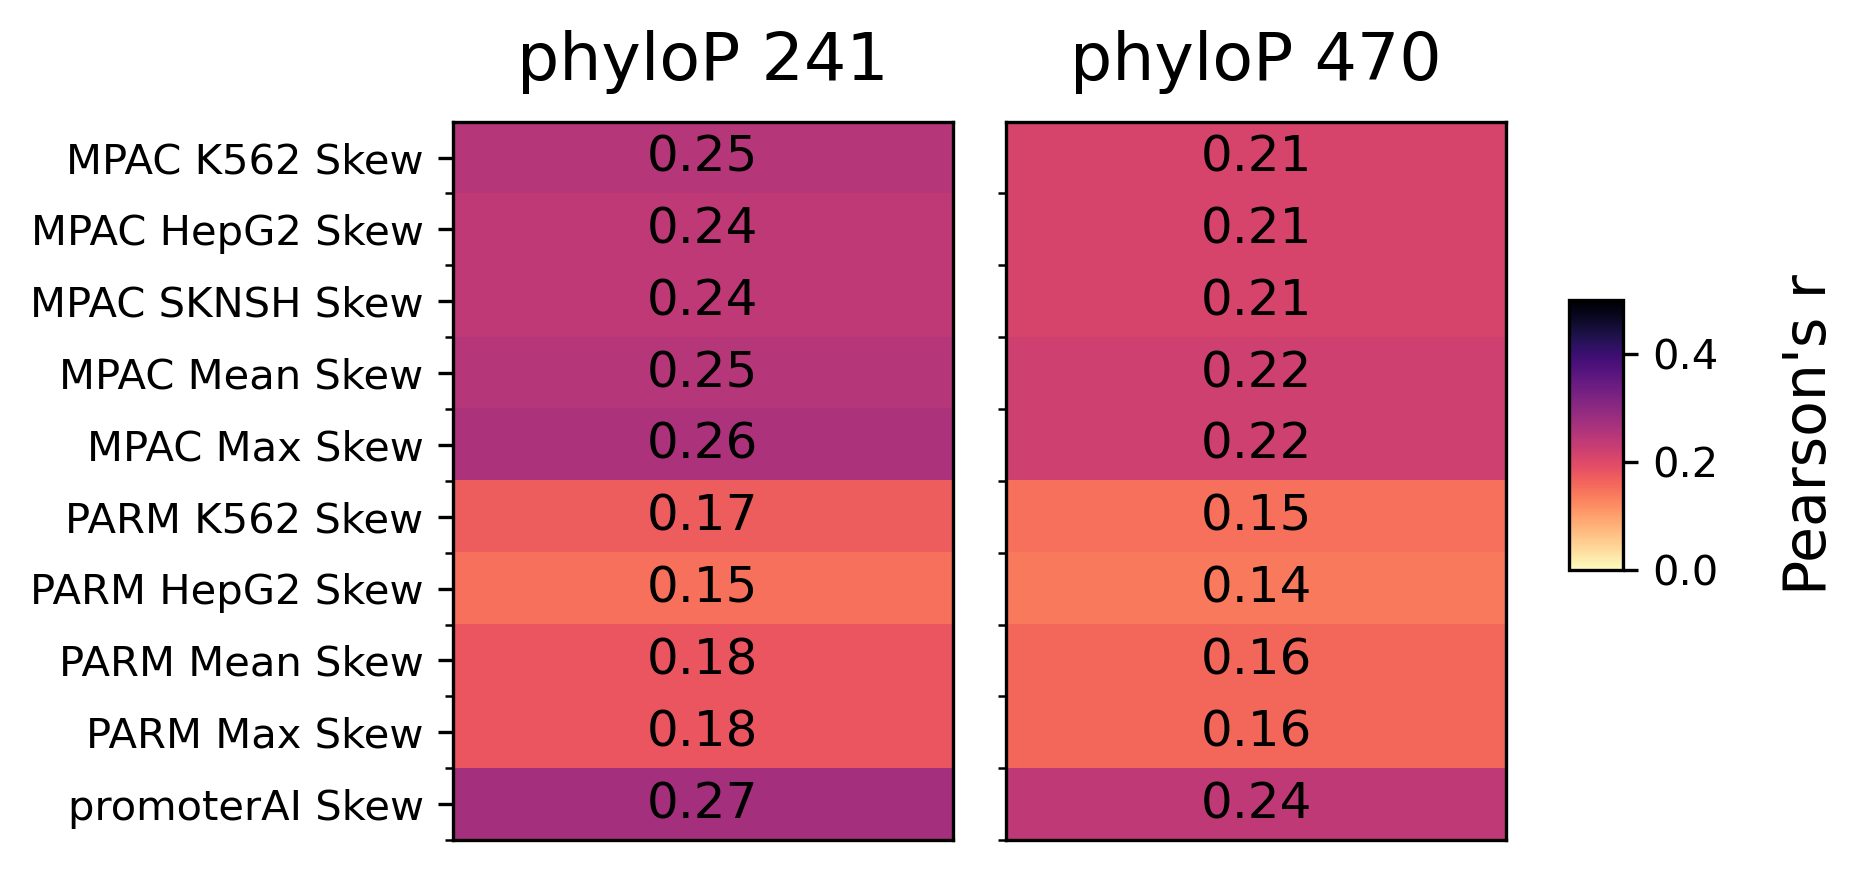

In [96]:
# Combine all data into a dictionary
labels = ['MPAC K562 Skew', 'MPAC HepG2 Skew', 'MPAC SKNSH Skew', 'MPAC Mean Skew', 'MPAC Max Skew',
          'PARM K562 Skew', 'PARM HepG2 Skew', 'PARM Mean Skew', 'PARM Max Skew',
          'promoterAI Skew']
data = {
    "phyloP 241": pd.Series(phyloP_241_corrs, index=labels),
    "phyloP 470": pd.Series(phyloP_470_corrs, index=labels),
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

cmap = 'magma_r'
vmin = 0.0
vmax = 0.5
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=16, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('')
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)

for i in range(1, 2):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Pearson's r", fontsize=14, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
plt.show()

/tmp/ipykernel_3526369/2886126470.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


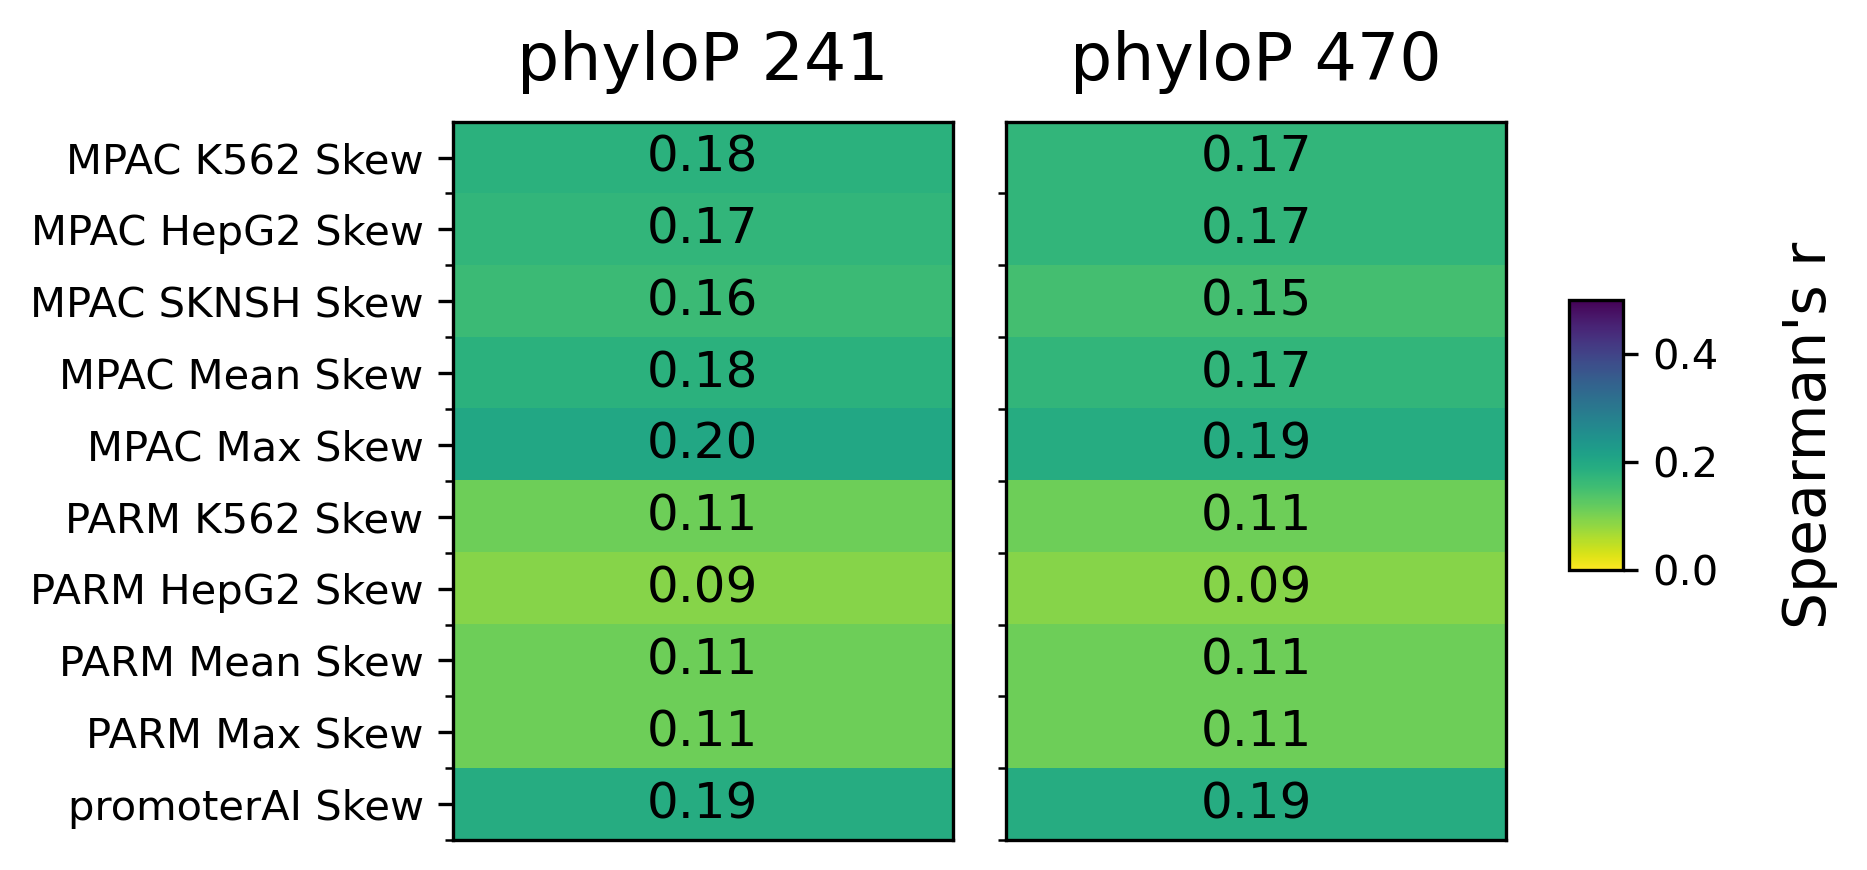

In [108]:
# Combine all data into a dictionary
labels = ['MPAC K562 Skew', 'MPAC HepG2 Skew', 'MPAC SKNSH Skew', 'MPAC Mean Skew', 'MPAC Max Skew',
          'PARM K562 Skew', 'PARM HepG2 Skew', 'PARM Mean Skew', 'PARM Max Skew',
          'promoterAI Skew']
data = {
    "phyloP 241": pd.Series(phyloP_241_corrs_spear, index=labels),
    "phyloP 470": pd.Series(phyloP_470_corrs_spear, index=labels),
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

cmap = 'viridis_r'
vmin = 0.0
vmax = 0.5
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=16, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('')
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)

for i in range(1, 2):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Spearman's r", fontsize=14, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
plt.show()

In [128]:
# compute correlations for each mpac skew prediction
# mpac vs. promoterAI - only active genes
labels = []
proAI_corrs_active = []
proAI_corrs_inactive = []
# compute correlations for promoterAI
for skew, idees in zip(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew'],
                       [k_expressed, h_expressed, s_expressed, expressed_any, expressed_any]):
    # update labels list
    labels.append(skew)
    # filter the df for only genes expressed in that cell type
    expressed_df = promoterAI_filtered_preds[promoterAI_filtered_preds['gene_id'].isin(idees)]
    # calculate correlation for that mpac column
    # promoterAI
    proAI_corrs_active.append(round(stats.pearsonr(x=expressed_df[skew], y=expressed_df['promoterAI_score'])[0], 2))
# compute correlations for promoterAI
for skew, idees in zip(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew'],
                       [k_expressed, h_expressed, s_expressed, expressed_any, expressed_any]):
    # update labels list
    labels.append(skew)
    # filter the df for only genes expressed in that cell type
    expressed_df = promoterAI_filtered_preds[~promoterAI_filtered_preds['gene_id'].isin(idees)]
    # calculate correlation for that mpac column
    # promoterAI
    proAI_corrs_inactive.append(round(stats.pearsonr(x=expressed_df[skew], y=expressed_df['promoterAI_score'])[0], 2))

/tmp/ipykernel_3526369/398885627.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


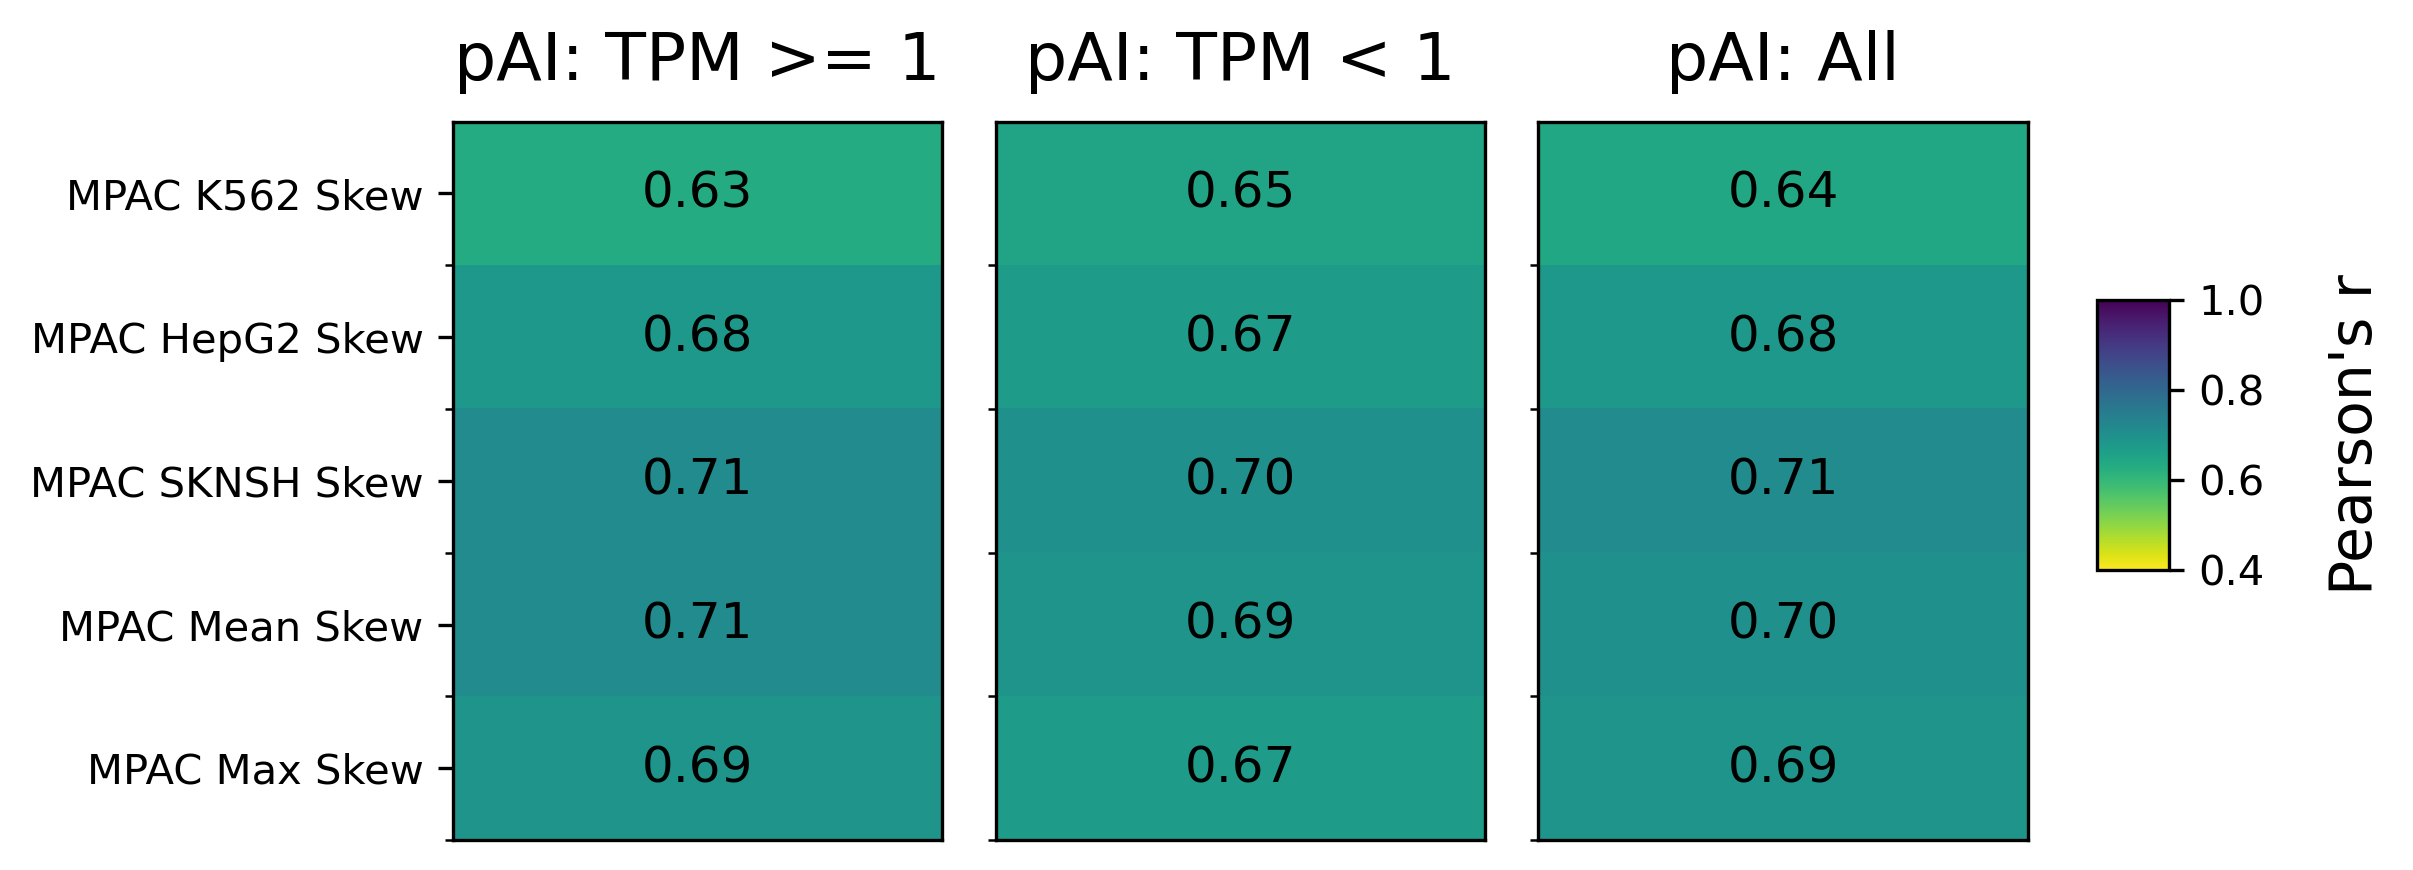

In [134]:
# Combine all data into a dictionary
labels = ['MPAC K562 Skew', 'MPAC HepG2 Skew', 'MPAC SKNSH Skew', 'MPAC Mean Skew', 'MPAC Max Skew']
data = {
    "pAI: TPM >= 1" : pd.Series(proAI_corrs_active, index=labels),
    "pAI: TPM < 1" : pd.Series(proAI_corrs_inactive, index=labels),
    "pAI: All" : pd.Series(proAI_corrs, index=labels),
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 3, figsize=(8, 3), dpi=300)

cmap = 'viridis_r'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=16, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('')
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)

for i in range(1, 3):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Pearson's r", fontsize=14, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
plt.show()

<Axes: >

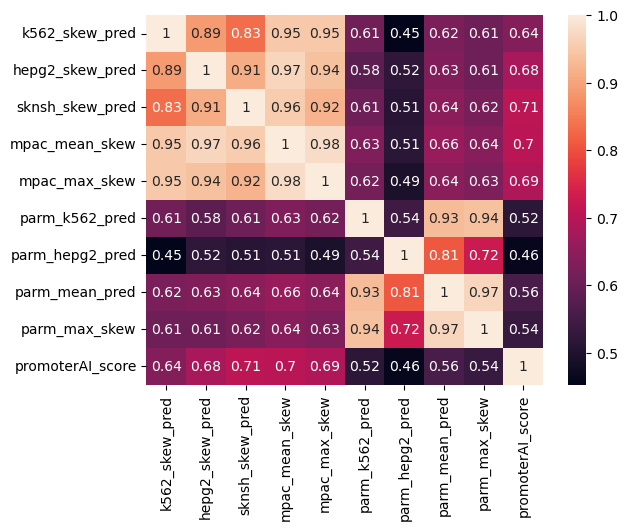

In [77]:
# let's try and make a quick heatmap 
df4heatmap = promoterAI_filtered_preds.filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew',
                                               'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew',
                                               'promoterAI_score']).corr()
sns.heatmap(df4heatmap, annot = True)

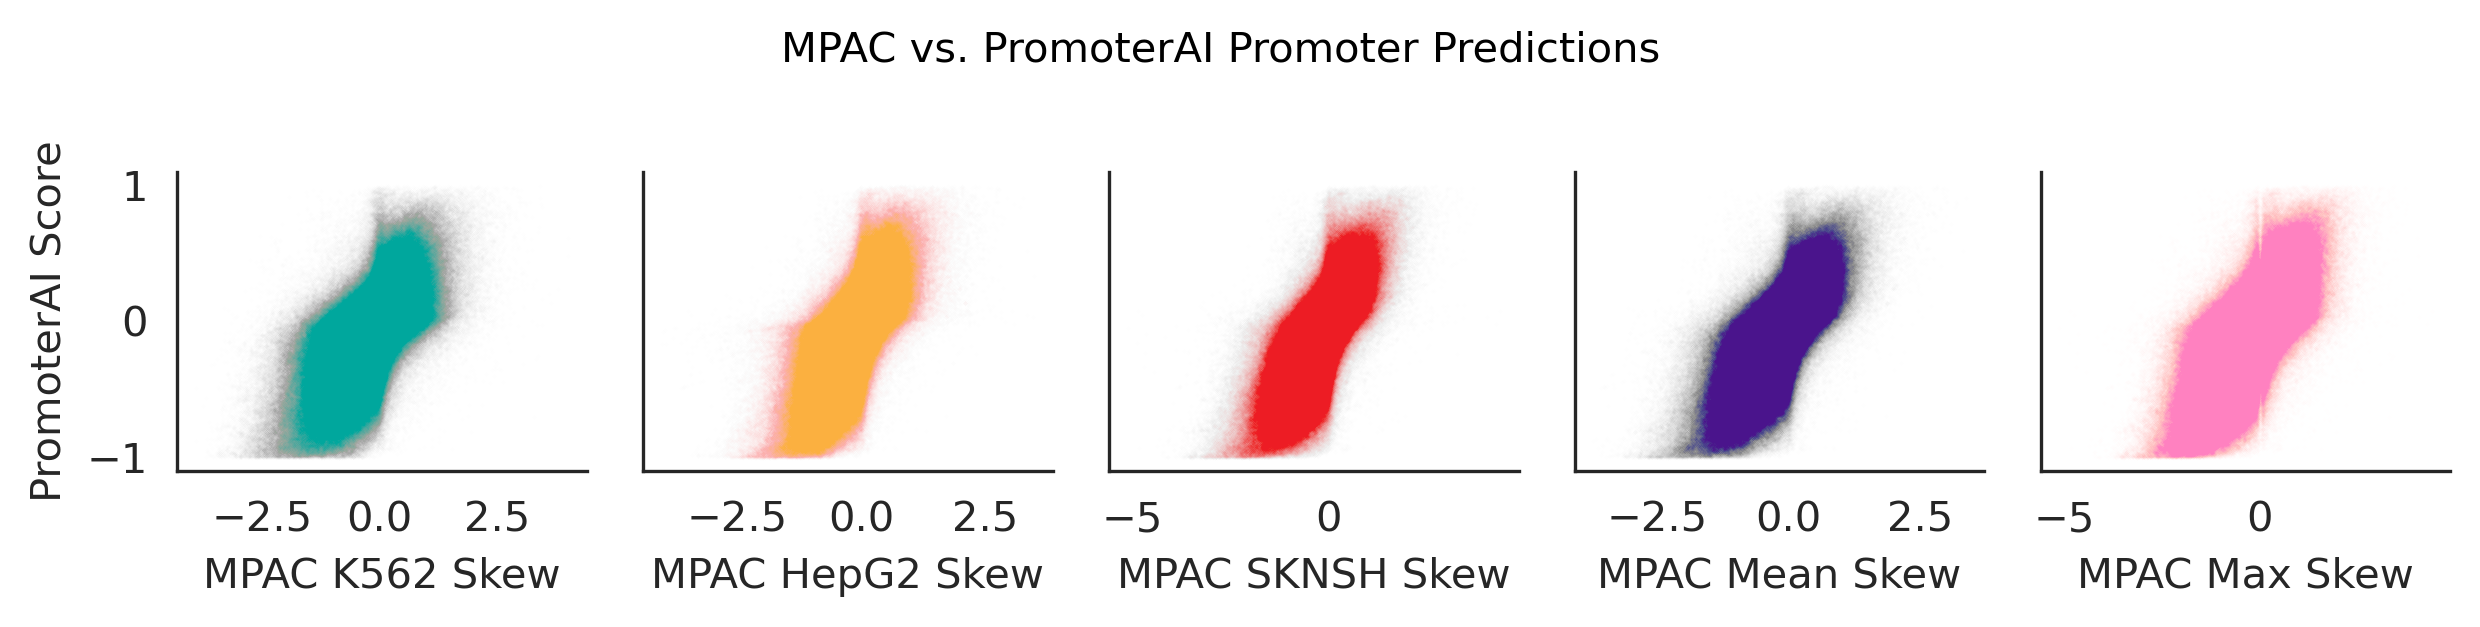

In [32]:
# plot correlations of mpac predictions to promoterAI
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,5)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# PromoterAI #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='k562_skew_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#00A79D',
        s=1,
        alpha=0.0025,
        ax=ax_01
    )
    ax_01.set_ylabel('PromoterAI Score')
    ax_01.set_xlabel('MPAC K562 Skew')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='hepg2_skew_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#FBB040',
        s=1,
        alpha=0.0025,
        ax=ax_02
    )
    ax_02.tick_params(axis='y', labelleft=False)
    ax_02.set_ylabel('')
    ax_02.set_xlabel('MPAC HepG2 Skew')
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='sknsh_skew_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#ED1C24',
        s=1,
        alpha=0.0025,
        ax=ax_03
    )
    ax_03.tick_params(axis='y', labelleft=False)
    ax_03.set_ylabel('')
    ax_03.set_xlabel('MPAC SKNSH Skew')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='mpac_mean_skew',
        y='promoterAI_score',
        rasterized=True,
        color='#4A148C',
        s=1,
        alpha=0.0025,
        ax=ax_04
    )
    ax_04.tick_params(axis='y', labelleft=False)
    ax_04.set_ylabel('')
    ax_04.set_xlabel('MPAC Mean Skew')
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='mpac_max_skew',
        y='promoterAI_score',
        rasterized=True,
        color='#FF81C0',
        s=1,
        alpha=0.0025,
        ax=ax_05
    )
    ax_05.tick_params(axis='y', labelleft=False)
    ax_05.set_ylabel('')
    ax_05.set_xlabel('MPAC Max Skew')
sns.despine()
f.suptitle(
    'MPAC vs. PromoterAI Promoter Predictions', 
    fontsize=10, 
    y=1.02      
)
plt.tight_layout()
plt.savefig('mpac_promoterAI_scatterplots_120325.pdf')

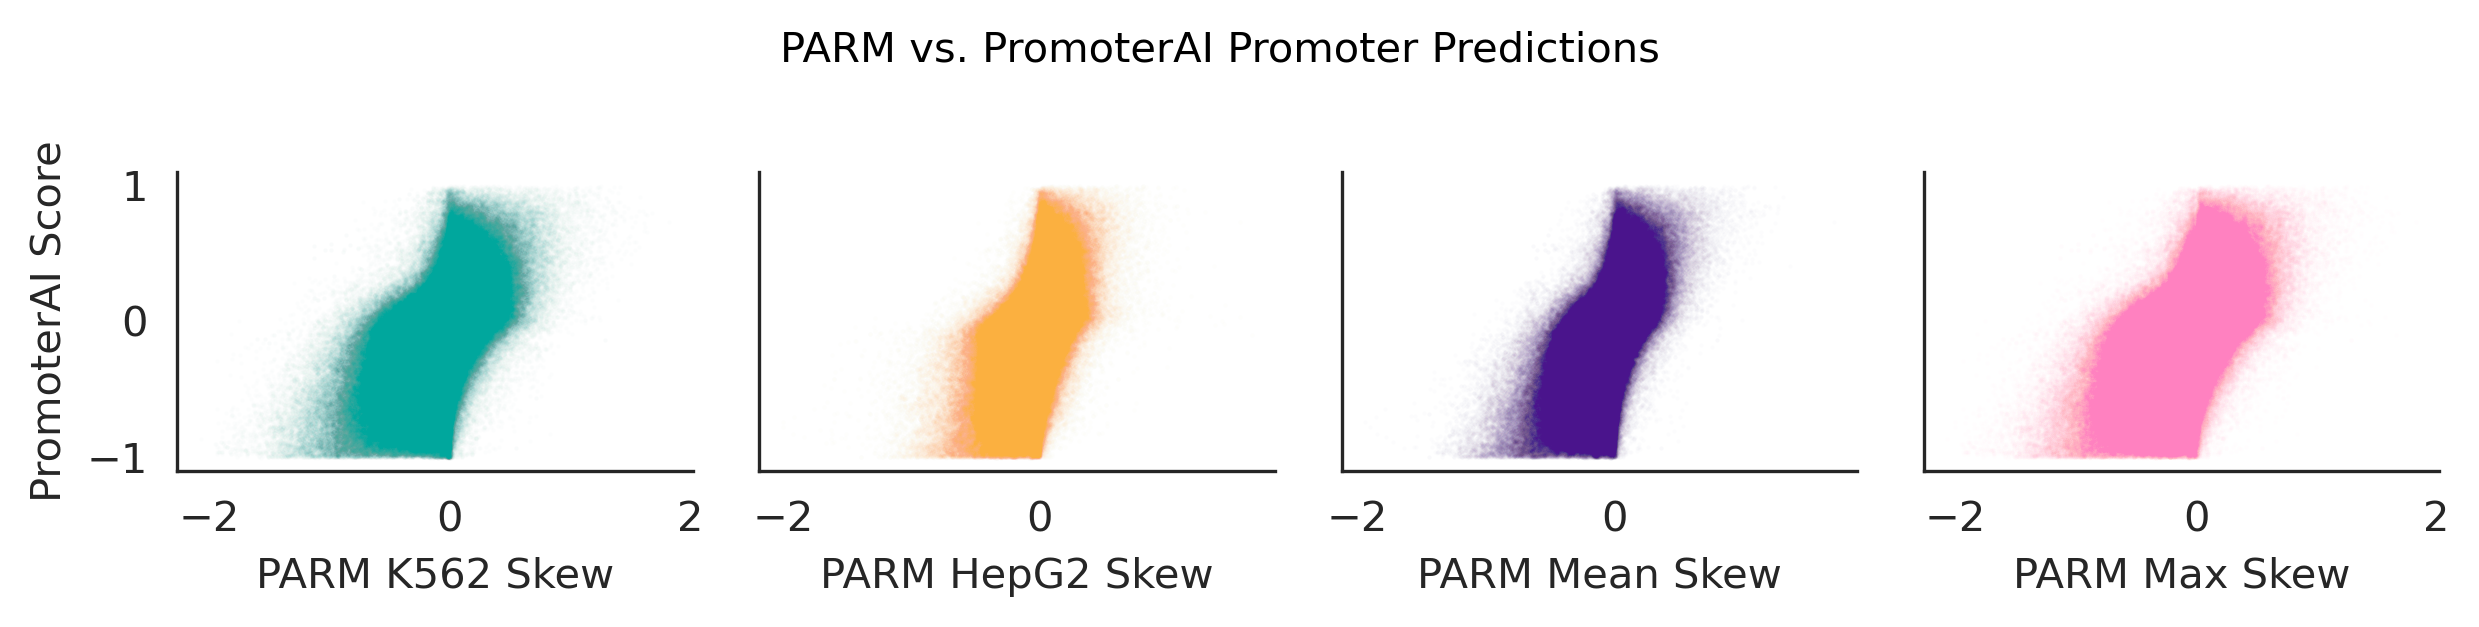

In [15]:
# plot correlations of parm predictions to promoterAI
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,4)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# PromoterAI #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='parm_k562_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#00A79D',
        s=1,
        alpha=0.01,
        ax=ax_01
    )
    ax_01.set_ylabel('PromoterAI Score')
    ax_01.set_xlabel('PARM K562 Skew')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)

    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='parm_hepg2_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#FBB040',
        s=1,
        alpha=0.01,
        ax=ax_02
    )
    ax_02.tick_params(axis='y', labelleft=False)
    ax_02.set_ylabel('')
    ax_02.set_xlabel('PARM HepG2 Skew')
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)

    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='parm_mean_pred',
        y='promoterAI_score',
        rasterized=True,
        color='#4A148C',
        s=1,
        alpha=0.01,
        ax=ax_03
    )
    ax_03.tick_params(axis='y', labelleft=False)
    ax_03.set_ylabel('')
    ax_03.set_xlabel('PARM Mean Skew')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    sns.scatterplot(
        data = promoterAI_filtered_preds,
        x='parm_max_skew',
        y='promoterAI_score',
        rasterized=True,
        color='#FF81C0',
        s=1,
        alpha=0.01,
        ax=ax_04
    )
    ax_04.tick_params(axis='y', labelleft=False)
    ax_04.set_ylabel('')
    ax_04.set_xlabel('PARM Max Skew')
sns.despine()
f.suptitle(
    'PARM vs. PromoterAI Promoter Predictions', 
    fontsize=10, 
    y=1.02      
)
plt.tight_layout()
plt.savefig('parm_promoterAI_scatterplots_120325.pdf')

In [12]:
promoterAI_filtered_preds.keys()

Index(['chrom', 'pos', 'id', 'ref', 'alt', 'k562_ref_pred', 'k562_alt_pred',
       'k562_skew_pred', 'hepg2_ref_pred', 'hepg2_alt_pred', 'hepg2_skew_pred',
       'sknsh_ref_pred', 'sknsh_alt_pred', 'sknsh_skew_pred', 'gene_id',
       'transcript_id', 'hgnc_id', 'merge_id', 'k562_mean_ref',
       'hepg2_mean_ref', 'sknsh_mean_ref', 'k562_mean_active',
       'hepg2_mean_active', 'sknsh_mean_active', 'mean_active_any',
       'k562_emVar', 'hepg2_emVar', 'sknsh_emVar', 'emVar_any', 'emVar_all',
       'k562_rna_tpm', 'hepg2_rna_tpm', 'sknsh_rna_tpm', 'hepg2_parm_act',
       'k562_parm_act', 'promoterAI_score', 'parm_k562_pred',
       'parm_hepg2_pred', 'parm_mean_pred', 'parm_k562_emVar',
       'parm_hepg2_emVar', 'parm_emVar_any', 'mpac_mean_skew', 'mpac_max_skew',
       'parm_max_skew', 'var_id', 'phyloP_470', 'phyloP_241'],
      dtype='object')

In [13]:
# let's get the correlations at the promoter level
# MPAC vs. PromoterAI - K562
mpac_proAI_prom_k562 = promoterAI_filtered_preds.filter(['promoterAI_score', 'k562_skew_pred', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# add k562 rna expression
k562_rna_dict = dict(zip(promoterAI_filtered_preds['gene_id'], promoterAI_filtered_preds['k562_rna_tpm']))
k562_pAI_corr_dict = dict(zip(mpac_proAI_prom_k562['gene_id'], mpac_proAI_prom_k562['k562_skew_pred']))
# add to df
mpac_proAI_prom_k562.loc[:, 'k562_rna_tpm'] = [k562_rna_dict.get(i) for i in mpac_proAI_prom_k562['gene_id']]
# MPAC vs. PromoterAI - HepG2
mpac_proAI_prom_hepg2 = promoterAI_filtered_preds.filter(['promoterAI_score', 'hepg2_skew_pred', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# add k562 rna expression
hepg2_rna_dict = dict(zip(promoterAI_filtered_preds['gene_id'], promoterAI_filtered_preds['hepg2_rna_tpm']))
hepg2_pAI_corr_dict = dict(zip(mpac_proAI_prom_hepg2['gene_id'], mpac_proAI_prom_hepg2['hepg2_skew_pred']))
# add to df
mpac_proAI_prom_hepg2.loc[:, 'hepg2_rna_tpm'] = [hepg2_rna_dict.get(i) for i in mpac_proAI_prom_hepg2['gene_id']]
# MPAC vs. PromoterAI - SKNSH
mpac_proAI_prom_sknsh = promoterAI_filtered_preds.filter(['promoterAI_score', 'sknsh_skew_pred', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# add k562 rna expression
sknsh_rna_dict = dict(zip(promoterAI_filtered_preds['gene_id'], promoterAI_filtered_preds['sknsh_rna_tpm']))
sknsh_pAI_corr_dict = dict(zip(mpac_proAI_prom_sknsh['gene_id'], mpac_proAI_prom_sknsh['sknsh_skew_pred']))
# add to df
mpac_proAI_prom_sknsh.loc[:, 'sknsh_rna_tpm'] = [sknsh_rna_dict.get(i) for i in mpac_proAI_prom_sknsh['gene_id']]
# MPAC vs. PromoterAI - Mean
mpac_proAI_prom_mean = promoterAI_filtered_preds.filter(['promoterAI_score', 'mpac_mean_skew', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
mpacMean_pAI_corr_dict = dict(zip(mpac_proAI_prom_mean['gene_id'], mpac_proAI_prom_mean['mpac_mean_skew']))
# MPAC vs. PromoterAI - Max
mpac_proAI_prom_max = promoterAI_filtered_preds.filter(['promoterAI_score', 'mpac_max_skew', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
mpacMax_pAI_corr_dict = dict(zip(mpac_proAI_prom_max['gene_id'], mpac_proAI_prom_max['mpac_max_skew']))

In [14]:
# let's get the promoter level correlations for MPAC and PARM
# k562
mpac_parm_prom_k562 = promoterAI_filtered_preds.filter(['parm_k562_pred', 'k562_skew_pred', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# make a dictionary
k562_parm_corr_dict = dict(zip(mpac_parm_prom_k562['gene_id'], mpac_parm_prom_k562['k562_skew_pred']))
# hepg2
mpac_parm_prom_hepg2 = promoterAI_filtered_preds.filter(['parm_hepg2_pred', 'hepg2_skew_pred', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# make a dictionary
hepg2_parm_corr_dict = dict(zip(mpac_parm_prom_hepg2['gene_id'], mpac_parm_prom_hepg2['hepg2_skew_pred']))
# mean
mean_parm_mpac_prom = promoterAI_filtered_preds.filter(['parm_mean_pred', 'mpac_mean_skew', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# make a dictionary
mean_parm_mpac_corr_dict = dict(zip(mean_parm_mpac_prom['gene_id'], mean_parm_mpac_prom['mpac_mean_skew']))
# max
max_parm_mpac_prom = promoterAI_filtered_preds.filter(['parm_max_skew', 'mpac_max_skew', 'gene_id']).groupby('gene_id').corr().iloc[::2,-1].reset_index()
# make a dictionary
max_parm_mpac_corr_dict = dict(zip(max_parm_mpac_prom['gene_id'], max_parm_mpac_prom['mpac_max_skew']))

In [15]:
# let's get the promoter level correlations for PARM and promoterAI
# k562
parm_pAI_prom_k562 = promoterAI_filtered_preds.filter(['parm_k562_pred', 'promoterAI_score', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# add k562 rna expression
k562_parm_pAI_corr_dict = dict(zip(parm_pAI_prom_k562['gene_id'], parm_pAI_prom_k562['promoterAI_score']))
# hepg2
parm_pAI_prom_hepg2 = promoterAI_filtered_preds.filter(['parm_hepg2_pred', 'promoterAI_score', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
# add k562 rna expression
hepg2_parm_pAI_corr_dict = dict(zip(parm_pAI_prom_hepg2['gene_id'], parm_pAI_prom_hepg2['promoterAI_score']))
# mean
parm_pAI_prom_mean = promoterAI_filtered_preds.filter(['parm_mean_pred', 'promoterAI_score', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
mean_parm_pAI_corr_dict = dict(zip(parm_pAI_prom_mean['gene_id'], parm_pAI_prom_mean['promoterAI_score']))
# max
parm_pAI_prom_max = promoterAI_filtered_preds.filter(['parm_max_skew', 'promoterAI_score', 'gene_id']).groupby('gene_id').corr().iloc[0::2,-1].reset_index()
max_parm_pAI_corr_dict = dict(zip(parm_pAI_prom_max['gene_id'], parm_pAI_prom_max['promoterAI_score']))

In [39]:
mpac_proAI_corrs = []
cell_types = []
gene_id = []
expressed = []
for i in tqdm(mpac_proAI_prom_k562['gene_id']):
    # add correlations
    # k562
    mpac_proAI_corrs.append(k562_pAI_corr_dict.get(i))
    cell_types.append('K562')
    gene_id.append(i)
    if i in k_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # hepg2
    mpac_proAI_corrs.append(hepg2_pAI_corr_dict.get(i))
    cell_types.append('HepG2')
    gene_id.append(i)
    if i in h_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # sknsh
    mpac_proAI_corrs.append(sknsh_pAI_corr_dict.get(i))
    cell_types.append('SKNSH')
    gene_id.append(i)
    if i in s_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # mean
    mpac_proAI_corrs.append(mpacMean_pAI_corr_dict.get(i))
    cell_types.append('Mean')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # max
    mpac_proAI_corrs.append(mpacMax_pAI_corr_dict.get(i))
    cell_types.append('Max')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
mpac_proAI_corr4violin = pd.DataFrame({'correlation' : mpac_proAI_corrs,
                                       'cell type' : cell_types,
                                       'gene_id' : gene_id,
                                       'expressed' : expressed})
# add label for MPAC
mpac_proAI_corr4violin.loc[:, 'Model'] = ['MPAC' for i in range(len(mpac_proAI_corr4violin))]

100%|██████████| 17366/17366 [00:09<00:00, 1844.58it/s]


In [54]:
mpac_parm_corrs = []
cell_types = []
gene_id = []
expressed = []
for i in mpac_parm_prom_k562['gene_id']:
    # add correlations
    # k562
    mpac_parm_corrs.append(k562_parm_corr_dict.get(i))
    cell_types.append('K562')
    gene_id.append(i)
    if i in k_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # hepg2
    mpac_parm_corrs.append(hepg2_parm_corr_dict.get(i))
    cell_types.append('HepG2')
    gene_id.append(i)
    if i in h_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # mean
    mpac_parm_corrs.append(mean_parm_mpac_corr_dict.get(i))
    cell_types.append('Mean')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # max
    mpac_parm_corrs.append(max_parm_mpac_corr_dict.get(i))
    cell_types.append('Max')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
mpac_parm_corr4violin = pd.DataFrame({'correlation' : mpac_parm_corrs,
                                       'cell type' : cell_types,
                                       'gene_id' : gene_id,
                                       'expressed' : expressed})

In [55]:
parm_proAI_corrs = []
cell_types = []
gene_id = []
expressed = []
for i in mpac_parm_prom_k562['gene_id']:
    # add correlations
    # k562
    parm_proAI_corrs.append(k562_parm_pAI_corr_dict.get(i))
    cell_types.append('K562')
    gene_id.append(i)
    if i in k_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # hepg2
    parm_proAI_corrs.append(hepg2_parm_pAI_corr_dict.get(i))
    cell_types.append('HepG2')
    gene_id.append(i)
    if i in h_expressed:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # mean
    parm_proAI_corrs.append(mean_parm_pAI_corr_dict.get(i))
    cell_types.append('Mean')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
    # max
    parm_proAI_corrs.append(max_parm_pAI_corr_dict.get(i))
    cell_types.append('Max')
    gene_id.append(i)
    if i in expressed_any:
        expressed.append('Expressed')
    else:
        expressed.append('Not Expressed')
parm_proAI_corr4violin = pd.DataFrame({'correlation' : parm_proAI_corrs,
                                       'cell type' : cell_types,
                                       'gene_id' : gene_id,
                                       'expressed' : expressed})
parm_proAI_corr4violin.loc[:, 'Model'] = ['PARM' for i in range(len(parm_proAI_corr4violin))]

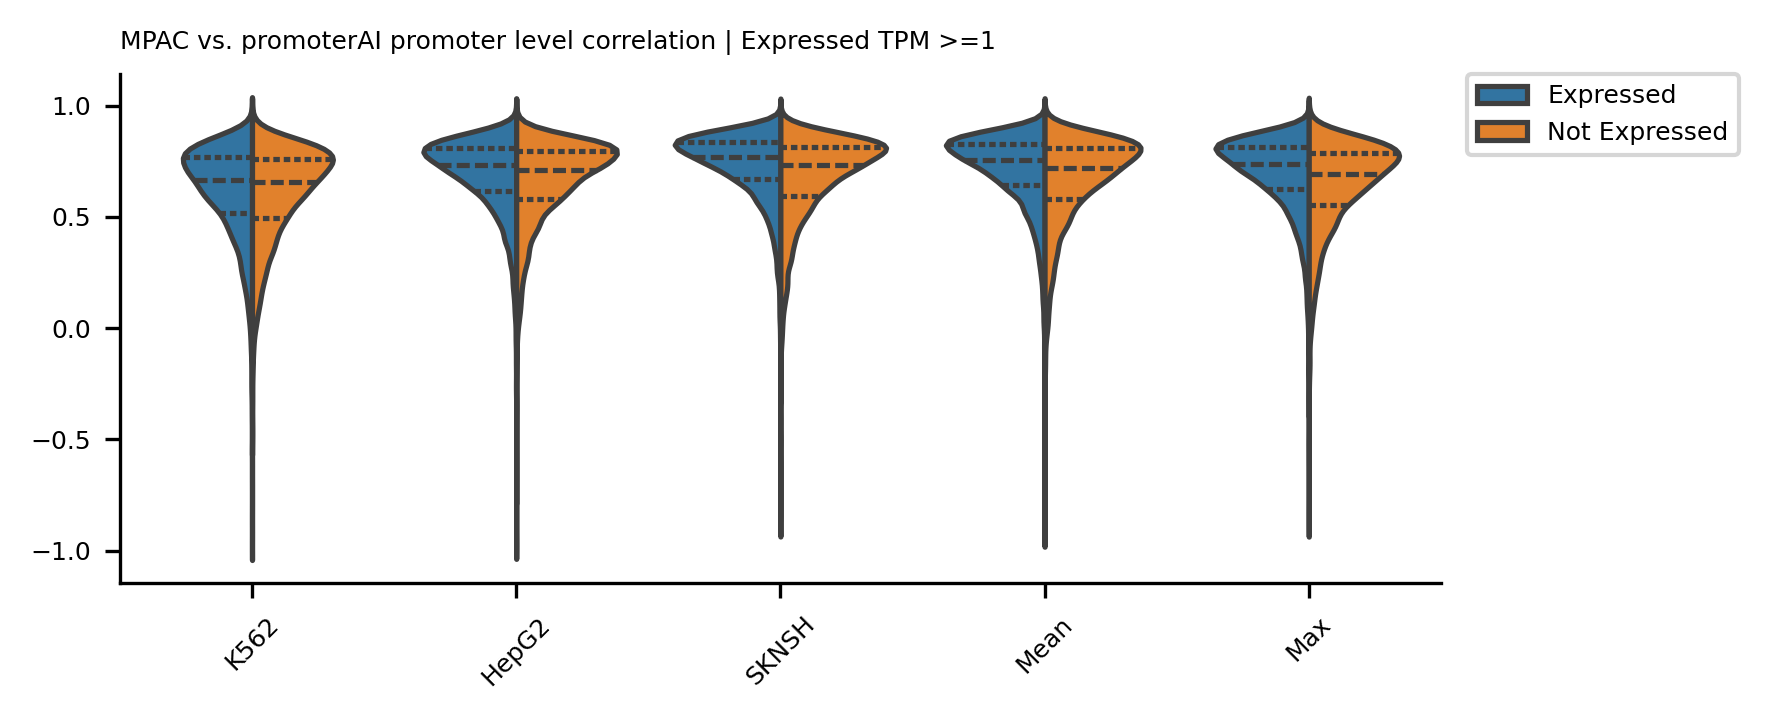

In [53]:
plt.figure(dpi=300, figsize = (6, 2.5))
sns.violinplot(
    data = mpac_proAI_corr4violin,
    x = 'cell type',
    y = 'correlation',
    hue = 'expressed',
    split = True,
    inner = 'quartile',
)
sns.despine()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize = 6)
plt.title('MPAC vs. promoterAI promoter level correlation | Expressed TPM >=1', loc = 'left', fontsize = 6)
plt.ylabel('Pearson', fontsize = 6)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, fontsize = 6)
plt.yticks(fontsize = 6)
plt.tight_layout()

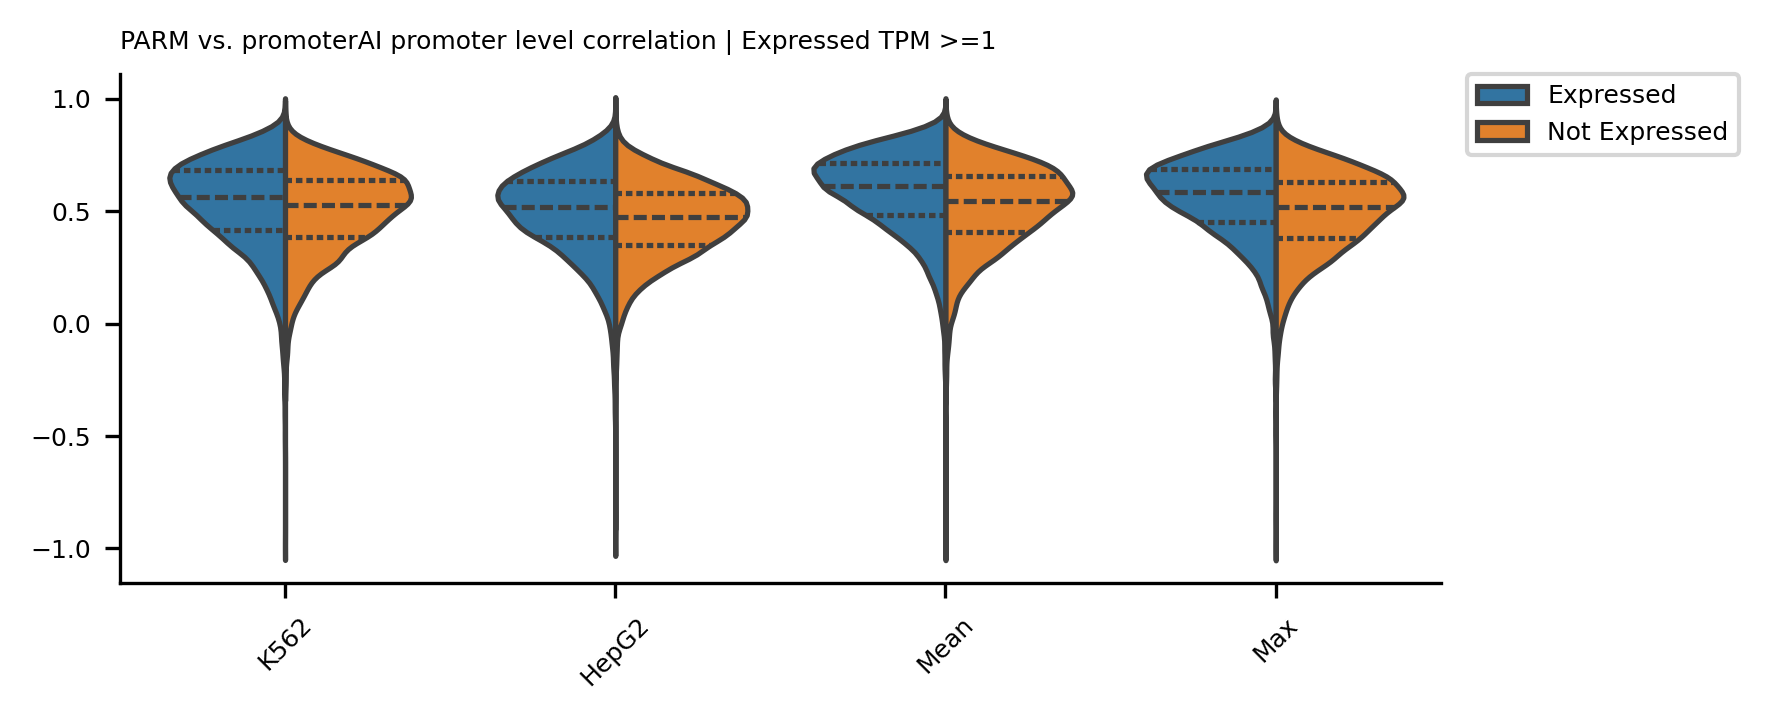

In [56]:
plt.figure(dpi=300, figsize = (6, 2.5))
sns.violinplot(
    data = parm_proAI_corr4violin,
    x = 'cell type',
    y = 'correlation',
    hue = 'expressed',
    split = True,
    inner = 'quartile',
)
sns.despine()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize = 6)
plt.title('PARM vs. promoterAI promoter level correlation | Expressed TPM >=1', loc = 'left', fontsize = 6)
plt.ylabel('Pearson', fontsize = 6)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, fontsize = 6)
plt.yticks(fontsize = 6)
plt.tight_layout()

In [60]:
# group correlation DFs for plotting on single panel, ie 'promoterAI is ground truth'
grouped_correlations = pd.concat([mpac_proAI_corr4violin, parm_proAI_corr4violin, mpac_parm_corr4violin])

In [57]:
# define a palette for coloring the violin plots
violin_palette = {'K562' : '#00A79D',
                  'HepG2' : '#FBB040',
                  'SKNSH': '#ED1C24',
                  'Mean' : '#4A148C',
                  'Max' : '#FF81C0'}

/tmp/ipykernel_3526369/2571826365.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3526369/2571826365.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_3526369/2571826365.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


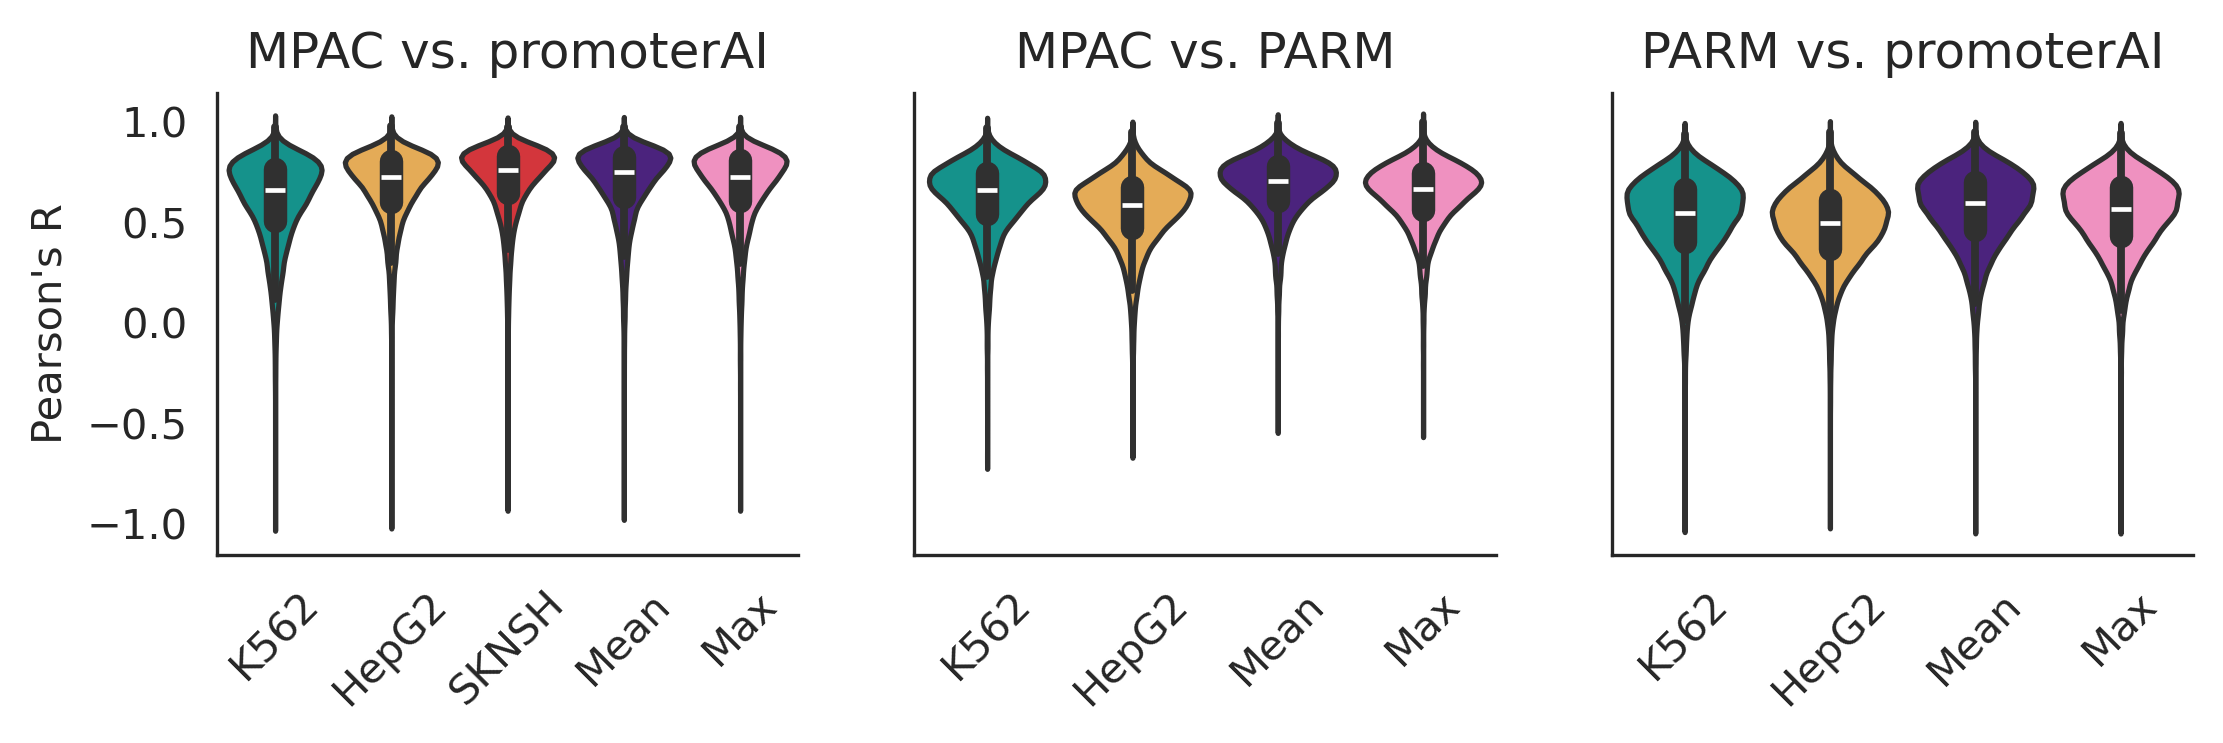

In [58]:
# plot correlations of mpac predictions to promoterAI
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    sns.violinplot(
        data = mpac_proAI_corr4violin,
        x = 'cell type',
        y = 'correlation',
        palette = violin_palette
    )
    ax_01.set_xlabel('')
    ax_01.set_ylabel('Pearson\'s R')
    plt.xticks(rotation=45)
    plt.title('MPAC vs. promoterAI')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey = ax_01)
    sns.violinplot(
        data = mpac_parm_corr4violin,
        x = 'cell type',
        y = 'correlation',
        palette = violin_palette
    )
    ax_02.tick_params(axis='y', labelleft=False)
    ax_02.set_ylabel('')
    ax_02.set_xlabel('')
    plt.xticks(rotation=45)
    plt.title('MPAC vs. PARM')
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey = ax_01)
    sns.violinplot(
        data = parm_proAI_corr4violin,
        x = 'cell type',
        y = 'correlation',
        palette = violin_palette
    )
    ax_03.tick_params(axis='y', labelleft=False)
    ax_03.set_ylabel('')
    ax_03.set_xlabel('')
    plt.xticks(rotation=45)
    plt.title('PARM vs. promoterAI')
sns.despine()
#plt.savefig('promoter_level_correlations_mpac_parm_promoterAI.pdf')

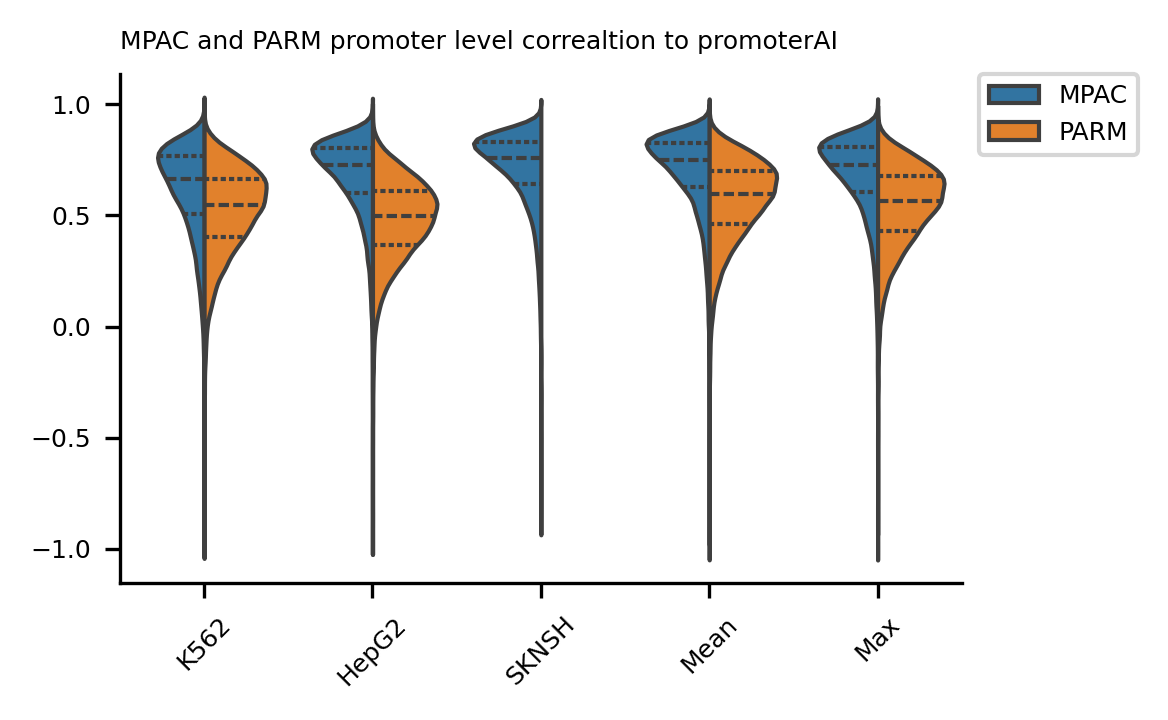

In [66]:
plt.figure(dpi=300, figsize = (4, 2.5))
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sns.violinplot(
    data = grouped_correlations,
    x = 'cell type',
    y = 'correlation',
    hue = 'Model',
    split = True,
    inner = 'quart',
    linewidth = 1
)
sns.despine()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize = 6)
plt.title('MPAC and PARM promoter level correaltion to promoterAI', loc = 'left', fontsize = 6)
plt.ylabel('Pearson', fontsize = 6)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, fontsize = 6)
plt.yticks(fontsize = 6)
plt.tight_layout()

/tmp/ipykernel_2842187/2293792694.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=90, fontsize=fontsize)
/tmp/ipykernel_2842187/2293792694.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=90, fontsize=fontsize)
/tmp/ipykernel_2842187/2293792694.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=90, fontsize=fontsize)


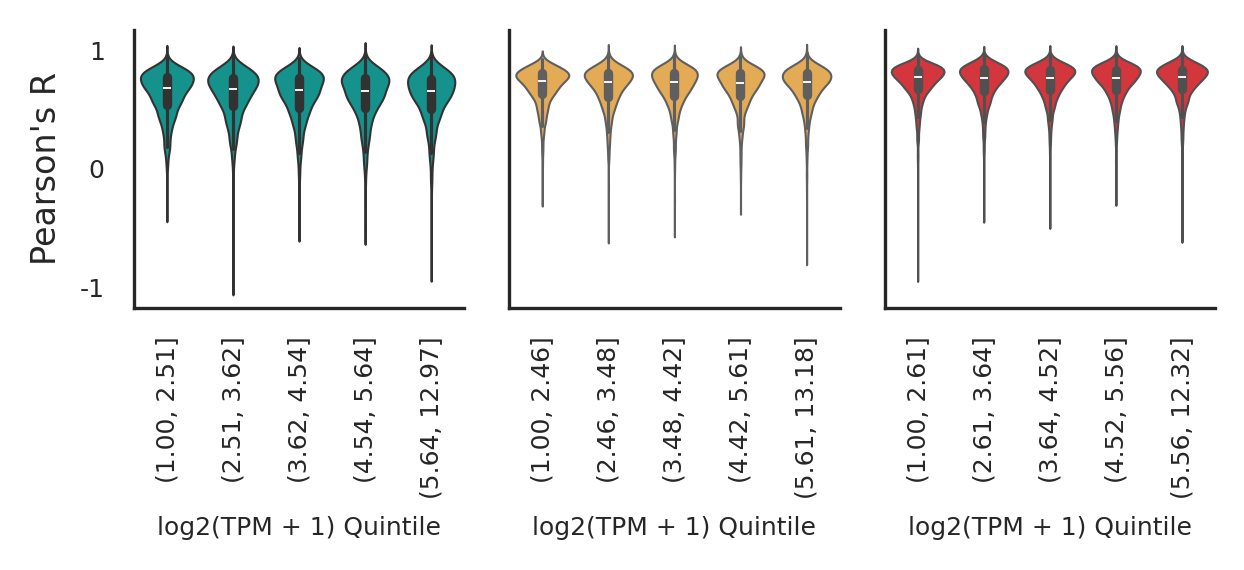

In [16]:
# plot correlations of mpac predictions to promoterAI
# binned by rna expression quintile
# minimum 1 TPM
f = mpl.figure(figsize=(4.25, 2), dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# PromoterAI #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    sns.violinplot(
        data = k562_mpac_proAI_expressed_corr,
        x='log2_tpm_quintile',
        y='k562_skew_pred',
        color='#00A79D',
        ax=ax_01,
        linewidth = 0.5
    )
    format_interval_labels(ax_01, fontsize = 6)
    ax_01.set_ylabel('Pearson\'s R', fontsize = 8)
    ax_01.set_yticks([-1,0,1], [-1,0,1], fontsize = 6)
    ax_01.set_xlabel('log2(TPM + 1) Quintile', fontsize = 6)
    mpl.xticks(rotation = 90)
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    sns.violinplot(
        data = hepg2_mpac_proAI_expressed_corr,
        x='log2_tpm_quintile',
        y='hepg2_skew_pred',
        color='#FBB040',
        ax=ax_02,
        linewidth = 0.5
    )
    format_interval_labels(ax_02, fontsize = 6)
    ax_02.set_ylabel('')
    ax_02.set_xlabel('log2(TPM + 1) Quintile', fontsize = 6)
    ax_02.tick_params(labelleft=False)
    mpl.xticks(rotation = 90)
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    sns.violinplot(
        data = sknsh_mpac_proAI_expressed_corr,
        x='log2_tpm_quintile',
        y='sknsh_skew_pred',
        color='#ED1C24',
        ax=ax_03,
        linewidth = 0.5
    )
    format_interval_labels(ax_03, fontsize = 6)
    ax_03.set_ylabel('')
    ax_03.set_xlabel('log2(TPM + 1) Quintile', fontsize = 6)
    ax_03.tick_params(labelleft=False)
    mpl.xticks(rotation = 90)
sns.despine()
mpl.tight_layout()
mpl.savefig('mpac_promoterAI_promoter_level_correlation_boxplots_112425.pdf')

In [44]:
# let's do the GTEx correlations
# open gtex fine mapped promoter eqtl dataset #
gtex_eqtl_bench = pd.read_csv('../raw_data/gtex_comparisons/GTEx_eQTL.tsv',
                              sep = '\t')
# add id in gtex format #
gtex_eqtl_bench['gtex_id'] = [('_').join([chrom, 
                                         str(pos), 
                                         ref, 
                                         alt]) + '_b38' for chrom, pos, ref, alt in zip(gtex_eqtl_bench['chrom'],
                                                                                 gtex_eqtl_bench['pos'],
                                                                                 gtex_eqtl_bench['ref'],
                                                                                 gtex_eqtl_bench['alt'])]
# get ids of the 'over/under' variants #
gtex_eqtl_over_under = gtex_eqtl_bench[gtex_eqtl_bench['consequence'].isin(['over', 'under'])]['gtex_id'].tolist()
gtex_eqtl_over = gtex_eqtl_bench[gtex_eqtl_bench['consequence'] =='over']['gtex_id'].tolist()
gtex_eqtl_under = gtex_eqtl_bench[gtex_eqtl_bench['consequence'] =='under']['gtex_id'].tolist()
gtex_eqtl_null = gtex_eqtl_bench[gtex_eqtl_bench['consequence'] =='none']['gtex_id'].tolist()

In [7]:
# open all gtex data #
all_gtex_data = [i for i in os.listdir('../raw_data/gtex_comparisons/GTEx_Data/GTEx_Analysis_v8_eQTL/') if i.endswith('v8.signif_variant_gene_pairs.txt.gz')]
# open all and concatenate into single df #
all_gtex_2cat = []
for tissueDF in all_gtex_data:
    # get the tissue
    tissue = tissueDF.split('.')[0]
    # open the df
    gtex = pd.read_csv(f'../raw_data/gtex_comparisons/GTEx_Data/GTEx_Analysis_v8_eQTL/{tissueDF}', sep = '\t')
    # add the tissue
    gtex.loc[:, 'tissue'] = [tissue for i in range(len(gtex))]
    # append the df to list
    all_gtex_2cat.append(gtex)
all_gtex_cat = pd.concat(all_gtex_2cat)

In [8]:
# add a column for filtering downstream - see after the promoterAI GTEx data
all_gtex_cat.loc[:,'pip_filter_id'] = [('_').join([id, gene, tissue]) for id, gene, tissue in zip(all_gtex_cat['variant_id'],
                                                                                                  all_gtex_cat['gene_id'],
                                                                                                  all_gtex_cat['tissue'])]

In [9]:
all_gtex_cat.head()

,variant_id,gene_id,tss_distance,ma_samples,ma_count,maf,pval_nominal,slope,slope_se,pval_nominal_threshold,min_pval_nominal,pval_beta,tissue,pip_filter_id
0,chr1_17005_A_G_b38,ENSG00000227232.5,-12548,17,17,0.017103,3.207170e-04,-0.680903,0.187703,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_17005_A_G_b38_ENSG00000227232.5_Esophagus...
1,chr1_64764_C_T_b38,ENSG00000227232.5,35211,64,65,0.065392,3.300840e-08,0.550227,0.097761,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_64764_C_T_b38_ENSG00000227232.5_Esophagus...
2,chr1_665098_G_A_b38,ENSG00000227232.5,635545,107,113,0.113682,3.392010e-09,0.457540,0.075776,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_665098_G_A_b38_ENSG00000227232.5_Esophagu...
3,chr1_666028_G_A_b38,ENSG00000227232.5,636475,97,103,0.103622,4.867940e-09,0.467178,0.078195,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_666028_G_A_b38_ENSG00000227232.5_Esophagu...
4,chr1_126108_G_A_b38,ENSG00000268903.1,-9787,67,67,0.067404,1.070960e-04,-0.424872,0.108648,0.000437,7.214120e-06,0.006632,Esophagus_Mucosa,chr1_126108_G_A_b38_ENSG00000268903.1_Esophagu...


In [10]:
# open gene name conversions grom g:Profile #
gprofile_gene_names = pd.read_csv('../raw_data/gtex_comparisons/gProfiler_hsapiens_manual_annotation.csv')
# make a dictionary of stable ID and gene name #
gprofile_stable_dict = dict(zip(gprofile_gene_names['converted_alias'], gprofile_gene_names['initial_alias']))
# make a dictionary of gene name and stable id #
gprofile_gene_name_key = dict(zip(gprofile_gene_names['name'], gprofile_gene_names['converted_alias']))

In [11]:
# add stable id to eqtl benchmark #
gtex_eqtl_bench['stable_id'] = [gprofile_gene_name_key.get(i) for i in gtex_eqtl_bench['gene']]

NameError: name 'gtex_eqtl_bench' is not defined

In [ ]:
# filter all gtex data for those in the test set #
gtex_bench = all_gtex_cat[all_gtex_cat['variant_id'].isin(gtex_eqtl_bench['gtex_id'].tolist())]
# convert the gene_id to stable ids #
gtex_bench.loc[:,'stable_id'] = [i.split('.')[0] for i in gtex_bench['gene_id']]
# get gene names from converted list #
gtex_bench.loc[:,'gene_name'] = [gprofile_stable_dict.get(i) for i in gtex_bench['stable_id']]

/tmp/ipykernel_2169761/1874254712.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtex_bench.loc[:,'stable_id'] = [i.split('.')[0] for i in gtex_bench['gene_id']]
/tmp/ipykernel_2169761/1874254712.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtex_bench.loc[:,'gene_name'] = [gprofile_stable_dict.get(i) for i in gtex_bench['stable_id']]


In [ ]:
# calculate average slope #
avg_slope = []
for variant, gene in zip(gtex_eqtl_bench['gtex_id'], gtex_eqtl_bench['stable_id']):
    # subset all benchmark variant gtex data #
    gene_var_subset = gtex_bench[(gtex_bench['stable_id'] == gene) & (gtex_bench['variant_id'] == variant)]
    avg_slope.append(np.mean(gene_var_subset['slope']))

In [ ]:
# open promoterAI preds #
promoterAI_preds = pd.read_csv('../raw_data/PrimateAI_and_PromoterAI_scores.hg38.tsv.gz',
                               sep = '\t')
# add 'id' column for making easy merge between datasets #
promoterAI_preds['merge_id'] = [(':').join([chrom,
                                      str(pos),
                                      ref,
                                      alt]) for chrom, pos, ref, alt in zip(promoterAI_preds['chrom'],
                                                                            promoterAI_preds['pos'],
                                                                            promoterAI_preds['ref'],
                                                                            promoterAI_preds['alt'])]
promoterAI_preds['gtex_id'] = [('_').join([chrom,
                                      str(pos),
                                      ref,
                                      alt]) + '_b38'for chrom, pos, ref, alt in zip(promoterAI_preds['chrom'],
                                                                            promoterAI_preds['pos'],
                                                                            promoterAI_preds['ref'],
                                                                            promoterAI_preds['alt'])]
# make a dict of promoter ai score gtex id #
pAI_gtex_score_dict = dict(zip(promoterAI_preds['gtex_id'], promoterAI_preds['PromoterAI_score']))
# drop NAs from promoterAI #
na_mask = promoterAI_preds['PromoterAI_score'].isna()
promoterAI_drop_na = promoterAI_preds.loc[~na_mask]
promoterAI_preds['gtex_id'] = [('_').join([chrom,
                                      str(pos),
                                      ref,
                                      alt]) + '_b38'for chrom, pos, ref, alt in zip(promoterAI_preds['chrom'],
                                                                            promoterAI_preds['pos'],
                                                                            promoterAI_preds['ref'],
                                                                            promoterAI_preds['alt'])]
# make a dict of promoter ai score gtex id #
pAI_gtex_score_dict = dict(zip(promoterAI_preds['gtex_id'], promoterAI_preds['PromoterAI_score']))

In [ ]:
# add average slope to gtex_eqtl_benchmark #
gtex_eqtl_bench.loc[:,'slope'] = avg_slope
# add promoterAI score to eqtl_benchmark #
gtex_eqtl_bench.loc[:,'promoterAI_score'] = [pAI_gtex_score_dict.get(i) for i in gtex_eqtl_bench['gtex_id']]

In [ ]:
# filter for only over and under variants #
gtex_eqtl_bench_over_under = gtex_eqtl_bench[gtex_eqtl_bench['consequence'].isin(['over', 'under'])]

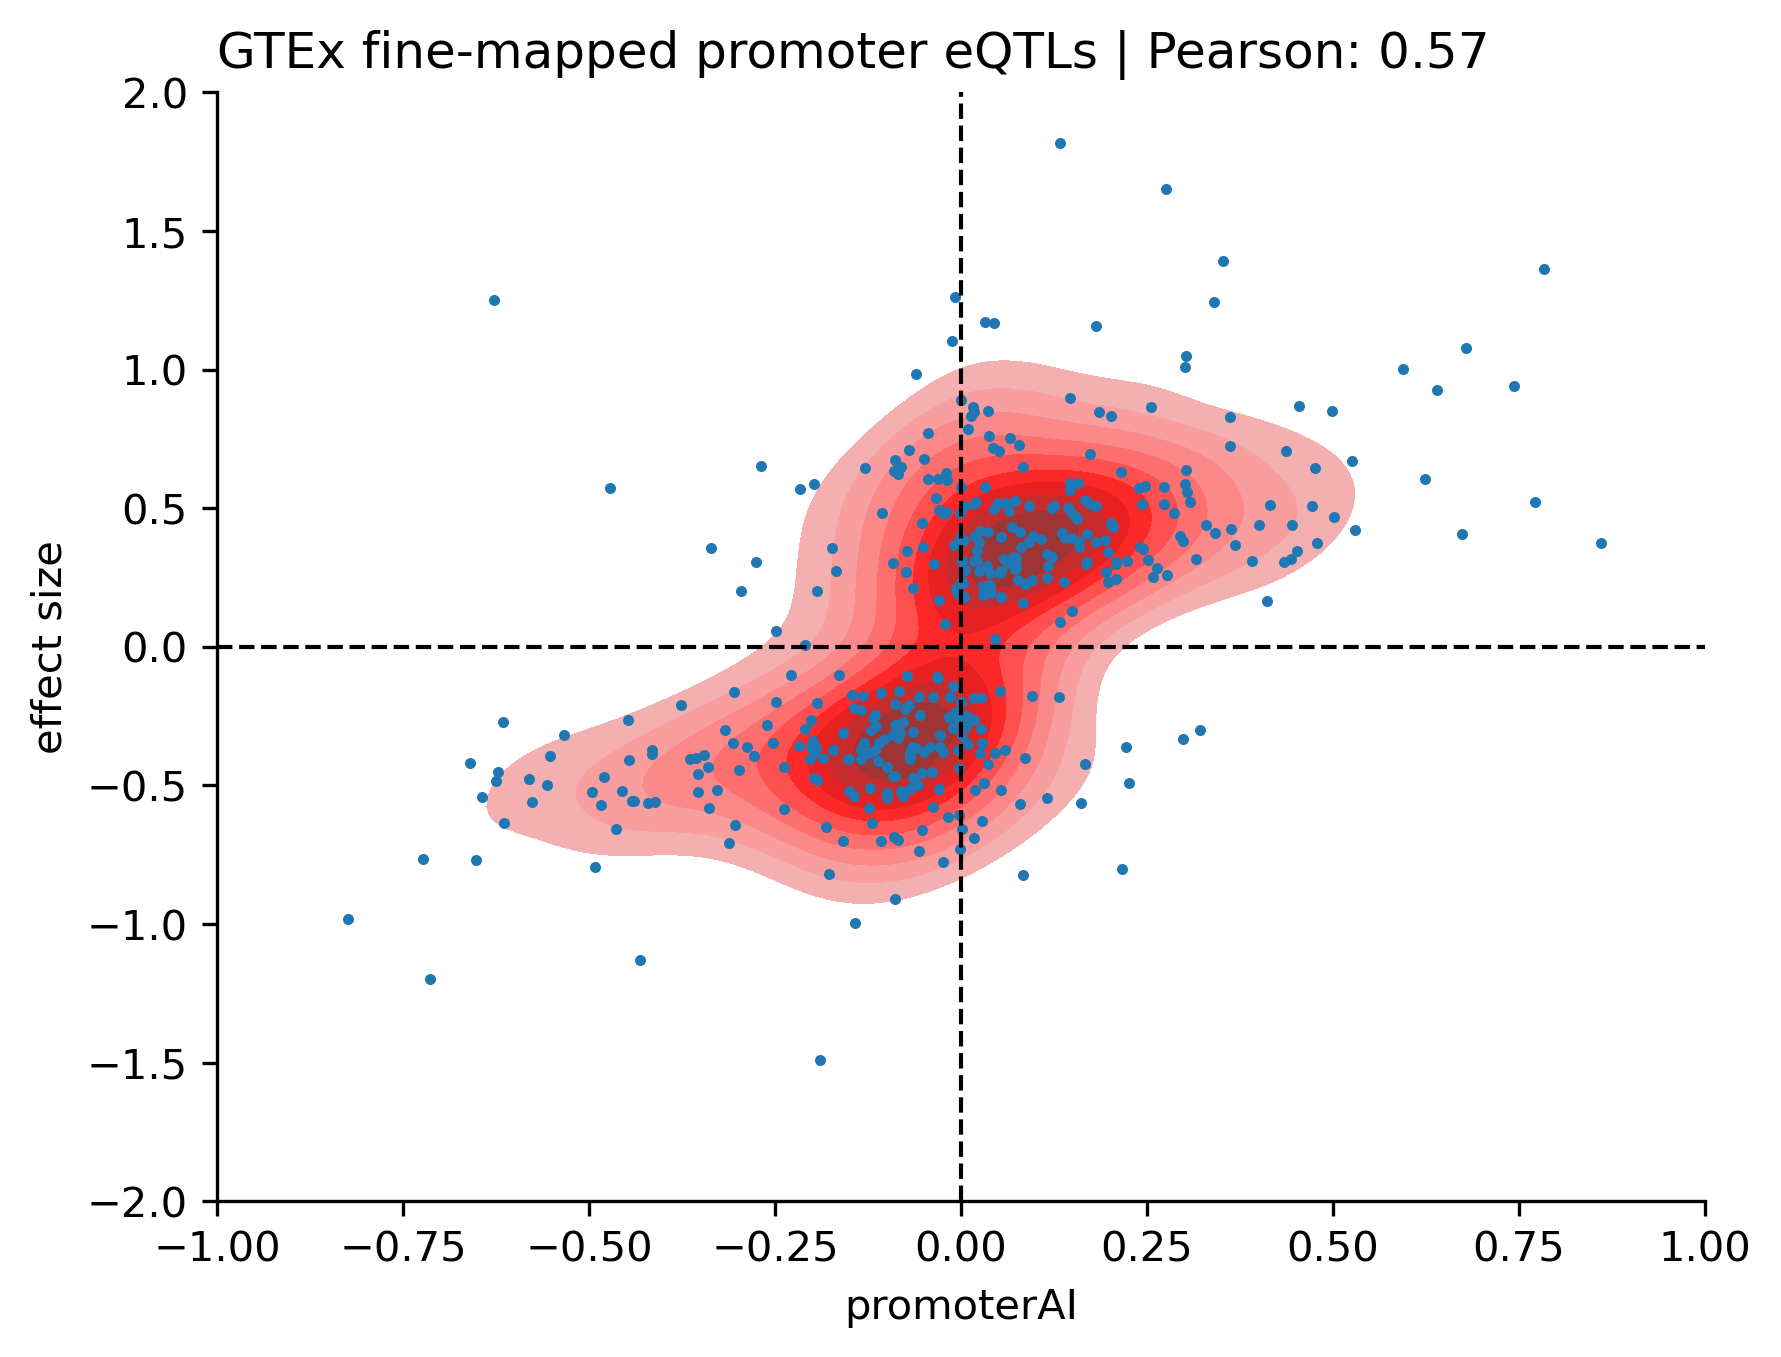

In [ ]:
# plot
mpl.figure(dpi=300)
sns.kdeplot(data=gtex_eqtl_bench_over_under,
                x='promoterAI_score',
                y='slope',
                fill=True,
                color='red',
                thresh=.2)
sns.scatterplot(data=gtex_eqtl_bench_over_under,
                x='promoterAI_score',
                y='slope',
                linewidth=0,
                s=7)
mpl.vlines(x=0, ymin=-2, ymax=2, linestyles='dashed', linewidth=1, color='k')
mpl.hlines(y=0, xmin=-1, xmax=1, linestyles='dashed', linewidth=1, color='k')
mpl.xlabel('promoterAI')
mpl.ylabel('effect size')
mpl.title(f'GTEx fine-mapped promoter eQTLs | Pearson: {round(stats.pearsonr(gtex_eqtl_bench_over_under['promoterAI_score'], gtex_eqtl_bench_over_under['slope'])[0],2)}', loc='left')
mpl.xlim(-1,1)
mpl.ylim(-2,2)
sns.despine()

In [ ]:
# make dictionaries of...
# gene : stable ID pairs for adding stable IDs to mpac DF for adding rna expression
hgnc_stableID_dict = dict(zip(gtex_eqtl_bench['gene'], gtex_eqtl_bench['stable_id']))
# gtex_id : slope
gtexID_slope_dict = dict(zip(gtex_eqtl_bench['gtex_id'], gtex_eqtl_bench['slope']))
# gtex_id promoterAI score
gtexID_promoterAI_dict = dict(zip(gtex_eqtl_bench['gtex_id'], gtex_eqtl_bench['promoterAI_score']))

In [ ]:
# open mpac predictions #
all_mpac = pd.concat([pd.read_csv(f'../raw_data/gtex_comparisons/mpac_017_preds/{i}', sep = '\t') for i in os.listdir('../raw_data/gtex_comparisons/mpac_017_preds/')])

In [ ]:
# filter all predicitons for only gtex eqtls #
mpac_mask = all_mpac['id'].str.startswith('GTEx_eQTL')
mpac_gtex_eqtl_bench = all_mpac.loc[mpac_mask]
# split out id column into strand, gene, consequence #
mpac_gtex_eqtl_bench.loc[:, 'strand'] = [i.split('_')[2] for i in mpac_gtex_eqtl_bench['id']]
mpac_gtex_eqtl_bench.loc[:, 'gene'] = [i.split('_')[3] for i in mpac_gtex_eqtl_bench['id']]
mpac_gtex_eqtl_bench.loc[:, 'consequence'] = [i.split('_')[-1] for i in mpac_gtex_eqtl_bench['id']]

/tmp/ipykernel_2169761/3276012558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'strand'] = [i.split('_')[2] for i in mpac_gtex_eqtl_bench['id']]
/tmp/ipykernel_2169761/3276012558.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'gene'] = [i.split('_')[3] for i in mpac_gtex_eqtl_bench['id']]
/tmp/ipykernel_2169761/3276012558.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [ ]:
# break out activity and skew predictions #
# ref activity
mpac_gtex_eqtl_bench.loc[:, 'k562_ref_pred'] = [float(i.split(';')[0].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_ref_pred'] = [float(i.split(';')[1].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_ref_pred'] = [float(i.split(';')[2].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
# alt activity
mpac_gtex_eqtl_bench.loc[:, 'k562_alt_pred'] = [float(i.split(';')[3].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_alt_pred'] = [float(i.split(';')[4].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_alt_pred'] = [float(i.split(';')[5].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
# 
mpac_gtex_eqtl_bench.loc[:, 'k562_active'] = [1 if max([ref, alt], key = abs) > 1 else 0 for ref, alt in zip(mpac_gtex_eqtl_bench['k562_ref_pred'], mpac_gtex_eqtl_bench['k562_alt_pred'])]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_active'] = [1 if max([ref, alt], key = abs) > 1 else 0 for ref, alt in zip(mpac_gtex_eqtl_bench['hepg2_ref_pred'], mpac_gtex_eqtl_bench['hepg2_alt_pred'])]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_active'] = [1 if max([ref, alt], key = abs) > 1 else 0 for ref, alt in zip(mpac_gtex_eqtl_bench['sknsh_ref_pred'], mpac_gtex_eqtl_bench['sknsh_alt_pred'])]
mpac_gtex_eqtl_bench.loc[:, 'active_any'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['k562_active'], mpac_gtex_eqtl_bench['hepg2_active'], mpac_gtex_eqtl_bench['sknsh_active'])]
# skew
mpac_gtex_eqtl_bench.loc[:, 'k562_skew_pred'] = [float(i.split(';')[6].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_skew_pred'] = [float(i.split(';')[7].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_skew_pred'] = [float(i.split(';')[8].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]

/tmp/ipykernel_2169761/1642433845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'active_any'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['k562_active'], mpac_gtex_eqtl_bench['hepg2_active'], mpac_gtex_eqtl_bench['sknsh_active'])]
/tmp/ipykernel_2169761/1642433845.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'k562_skew_pred'] = [float(i.split(';')[6].split('=')[-1]) for i in mpac_gtex_eqtl_bench['INFO']]
/tmp/ip

In [ ]:
# add mpac max and average #
mpac_gtex_eqtl_bench.loc[:, 'mpac_skew_avg'] = [np.mean([k,h,s]) for k,h,s in zip(mpac_gtex_eqtl_bench['k562_skew_pred'],
                                                                           mpac_gtex_eqtl_bench['hepg2_skew_pred'],
                                                                           mpac_gtex_eqtl_bench['sknsh_skew_pred'])]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_sknsh_avg'] = [np.mean([h,s]) for h,s in zip(mpac_gtex_eqtl_bench['hepg2_skew_pred'],
                                                                           mpac_gtex_eqtl_bench['sknsh_skew_pred'])]
mpac_gtex_eqtl_bench.loc[:, 'mpac_skew_max'] = [max([k,h,s], key=abs) for k,h,s in zip(mpac_gtex_eqtl_bench['k562_skew_pred'],
                                                                           mpac_gtex_eqtl_bench['hepg2_skew_pred'],
                                                                           mpac_gtex_eqtl_bench['sknsh_skew_pred'])]
# add gtex style id to df for merging #
mpac_gtex_eqtl_bench.loc[:, 'gtex_id'] = [('_').join([chrom,
                                               str(pos),
                                               ref,
                                               alt]) + '_b38' for chrom, pos, ref, alt in zip(mpac_gtex_eqtl_bench['chrom'],
                                                                                                                 mpac_gtex_eqtl_bench['pos'],
                                                                                                                 mpac_gtex_eqtl_bench['ref'],
                                                                                                                 mpac_gtex_eqtl_bench['alt'])]
# add stable id
mpac_gtex_eqtl_bench.loc[:, 'stable_id'] = [hgnc_stableID_dict.get(i) for i in mpac_gtex_eqtl_bench['gene']]
# add slope
mpac_gtex_eqtl_bench.loc[:, 'slope'] = [gtexID_slope_dict.get(i) for i in mpac_gtex_eqtl_bench['gtex_id']]
# add promoterAI score
mpac_gtex_eqtl_bench.loc[:, 'promoterAI_score'] = [gtexID_promoterAI_dict.get(i) for i in mpac_gtex_eqtl_bench['gtex_id']]

/tmp/ipykernel_2169761/4145203591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'mpac_skew_avg'] = [np.mean([k,h,s]) for k,h,s in zip(mpac_gtex_eqtl_bench['k562_skew_pred'],
/tmp/ipykernel_2169761/4145203591.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_bench.loc[:, 'hepg2_sknsh_avg'] = [np.mean([h,s]) for h,s in zip(mpac_gtex_eqtl_bench['hepg2_skew_pred'],
/tmp/ipykernel_2169761/4145203591.py:7: SettingWithCopyWarning: 
A value is trying to be set on a

In [ ]:
# add rna expression for each cell type
# reformat rna dictionary keys for matching to stable ids
# k562
k562_stableID_rna_dict = dict(zip([i.split('.')[0] for i in promoterAI_filtered_preds['gene_id']], promoterAI_filtered_preds['k562_rna_tpm']))
# hepg2
hepg2_stableID_rna_dict = dict(zip([i.split('.')[0] for i in promoterAI_filtered_preds['gene_id']], promoterAI_filtered_preds['hepg2_rna_tpm']))
# sksnh
sknsh_stableID_rna_dict = dict(zip([i.split('.')[0] for i in promoterAI_filtered_preds['gene_id']], promoterAI_filtered_preds['sknsh_rna_tpm']))

In [ ]:
# add rna expression to eqtl benchmarking set
mpac_gtex_eqtl_bench.loc[:, 'k562_rna_tpm'] = [k562_stableID_rna_dict.get(i) for i in mpac_gtex_eqtl_bench['stable_id']]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_rna_tpm'] = [hepg2_stableID_rna_dict.get(i) for i in mpac_gtex_eqtl_bench['stable_id']]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_rna_tpm'] = [sknsh_stableID_rna_dict.get(i) for i in mpac_gtex_eqtl_bench['stable_id']]
mpac_gtex_eqtl_bench.loc[:, 'expressed_any'] = [1 if max([k,h,s]) >= 1 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['k562_rna_tpm'], mpac_gtex_eqtl_bench['hepg2_rna_tpm'], mpac_gtex_eqtl_bench['sknsh_rna_tpm'])]

/tmp/ipykernel_2169761/3396454479.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0, 0.0, 0.4, 14.1, 14.1, 4.7, 4.7, 0.0, 0.0, 20.5, 1846.6, 1846.6, 1846.6, 1846.6, 1846.6, 1846.6, 1846.6, 1846.6, 14.1, 14.1, 0.0, 0.0, 0.0, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 0.1, 1.6, 0.0, 9.4, 9.4, 1.7, 24.8, 24.8, 24.8, 24.8, 55.6, 55.6, 55.6, 20.7, 20.7, 20.7, 4.2, 4.2, 4.2, 2.9, 30.2, 30.2, 0.1, 58.6, 58.6, 25.8, 25.8, 25.8, 4.5, 4.5, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 58.4, 58.4, 58.4, 58.4, 20.3, 3.0, 3.0, 0.0, 0.0, 0.0, 5.9, 0.1, 0.1, 0.1, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0, 17.6, 0.0, 0.0, 0.0, 22.8, 22.8, 0.0, 0.0, 0.0, 25.4, 105.9, 105.9, 105.9, 105.9, 12.0, 12.0, 12.0, 12.0, 12.0, 7.3, 7.3, 7.3, 7.3, 7.3, 7.3, 18.7, None, 147.1, 176.8, 176.8, 0.0, 0.0, 0.0, 0.0, 8.2, 629.7, 629.7, 33.3, 33.3, 33.3, 725.3, 0.3, 0.0, 0.0, 5.9, 0.0, 0.0, 0.0, None, None, None, None, None, None, 2.0, 2.0, 0.0, 15.1, 15.1, 41.4, 41.4, 0.8, 28.7, 

In [ ]:
# add annotation for whether something is an emVar in each cell type
mpac_gtex_eqtl_bench.loc[:, 'k562_emVar'] = [1 if abs(i) > 0.5 else 0 for i in mpac_gtex_eqtl_bench['k562_skew_pred']]
mpac_gtex_eqtl_bench.loc[:, 'hepg2_emVar'] = [1 if abs(i) > 0.5 else 0 for i in mpac_gtex_eqtl_bench['hepg2_skew_pred']]
mpac_gtex_eqtl_bench.loc[:, 'sknsh_emVar'] = [1 if abs(i) > 0.5 else 0 for i in mpac_gtex_eqtl_bench['sknsh_skew_pred']]
mpac_gtex_eqtl_bench.loc[:, 'emVar_any'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['k562_emVar'], mpac_gtex_eqtl_bench['hepg2_emVar'], mpac_gtex_eqtl_bench['sknsh_emVar'])]
mpac_gtex_eqtl_bench.loc[:, 'emVar_all'] = [1 if sum([k,h,s]) == 3 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['k562_emVar'], mpac_gtex_eqtl_bench['hepg2_emVar'], mpac_gtex_eqtl_bench['sknsh_emVar'])]

In [67]:
# add annotations for concordance of effect
# promoterAI
mpac_gtex_eqtl_bench.loc[:, 'promoterAI_concordant'] = [1 if pro_score > 0 and slope > 0 or pro_score < 0 and slope < 0 else 0 for pro_score, slope in zip(mpac_gtex_eqtl_bench['promoterAI_score'], mpac_gtex_eqtl_bench['slope'])]
# mpac k562
mpac_gtex_eqtl_bench.loc[:, 'mpac_k562_concordant'] = [1 if k_skew > 0 and slope > 0 or k_skew < 0 and slope < 0 else 0 for k_skew, slope in zip(mpac_gtex_eqtl_bench['k562_skew_pred'], mpac_gtex_eqtl_bench['slope'])]
# mpac hepg2
mpac_gtex_eqtl_bench.loc[:, 'mpac_hepg2_concordant'] = [1 if h_skew > 0 and slope > 0 or h_skew < 0 and slope < 0 else 0 for h_skew, slope in zip(mpac_gtex_eqtl_bench['hepg2_skew_pred'], mpac_gtex_eqtl_bench['slope'])]
# mpac sknsh
mpac_gtex_eqtl_bench.loc[:, 'mpac_sknsh_concordant'] = [1 if s_skew > 0 and slope > 0 or s_skew < 0 and slope < 0 else 0 for s_skew, slope in zip(mpac_gtex_eqtl_bench['sknsh_skew_pred'], mpac_gtex_eqtl_bench['slope'])]
# mpac any
mpac_gtex_eqtl_bench.loc[:, 'mpac_any_concordant'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(mpac_gtex_eqtl_bench['mpac_k562_concordant'], mpac_gtex_eqtl_bench['mpac_hepg2_concordant'], mpac_gtex_eqtl_bench['mpac_sknsh_concordant'])]

In [68]:
mpac_gtex_eqtl_over_under = mpac_gtex_eqtl_bench[mpac_gtex_eqtl_bench['consequence'].isin(['over', 'under'])]

In [69]:
mpac_gtex_eqtl_over_under.head()

,chrom,pos,id,ref,alt,INFO,strand,gene,consequence,k562_ref_pred,...,hepg2_emVar,sknsh_emVar,emVar_any,emVar_all,promoterAI_concordant,mpac_k562_concordant,mpac_hepg2_concordant,mpac_sknsh_concordant,mpac_any_concordant,expressed_any
64,chr3,2098694,GTEx_eQTL_1_CNTN4_over,C,A,K562__ref=3.967545;HepG2__ref=3.0688584;SKNSH_...,1,CNTN4,over,3.967545,...,0,0,0,0,1,0,0,1,1,1
65,chr3,8769477,GTEx_eQTL_-1_OXTR_over,A,G,K562__ref=2.8218358;HepG2__ref=1.9123546;SKNSH...,-1,OXTR,over,2.821836,...,0,0,0,0,1,1,1,1,1,1
66,chr3,8963418,GTEx_eQTL_-1_RAD18_under,C,T,K562__ref=4.5626493;HepG2__ref=3.3759713;SKNSH...,-1,RAD18,under,4.562649,...,0,0,0,0,1,0,0,0,0,1
69,chr3,12796685,GTEx_eQTL_1_CAND2_over,C,T,K562__ref=3.980242;HepG2__ref=3.3668349;SKNSH_...,1,CAND2,over,3.980242,...,0,0,0,0,1,1,1,1,1,1
71,chr3,19148202,GTEx_eQTL_1_KCNH8_under,C,G,K562__ref=1.9408131;HepG2__ref=4.0810533;SKNSH...,1,KCNH8,under,1.940813,...,0,0,0,0,0,1,0,1,1,0


In [70]:
# open parm predictions
# hepg2
all_parm_proBench_hepg2 = pd.read_csv('../../PARM/preds_out/promoterAI_benchmarking/mpacked_hepg2_promoterAI_benchmarking.tsv', sep = '\t')
# k562
all_parm_proBench_k562 = pd.read_csv('../../PARM/preds_out/promoterAI_benchmarking/mpacked_k562_promoterAI_benchmarking.tsv', sep = '\t')
# reformat ID column
all_parm_proBench_hepg2.loc[:, 'gtex_id'] = [('_').join(i.split(':')) + '_b38' for i in all_parm_proBench_hepg2['id']]
all_parm_proBench_k562.loc[:, 'gtex_id'] = [('_').join(i.split(':')) + '_b38' for i in all_parm_proBench_k562['id']]

In [71]:
# filter all parm benchmarking predictions for
parm_gtex_hepg2 = all_parm_proBench_hepg2[all_parm_proBench_hepg2['gtex_id'].isin(mpac_gtex_eqtl_over_under['gtex_id'].tolist())]
parm_gtex_k562 = all_parm_proBench_k562[all_parm_proBench_k562['gtex_id'].isin(mpac_gtex_eqtl_over_under['gtex_id'].tolist())]
# build dictionaries for adding the skews to the larger dataframe
parm_hepg2_dict = dict(zip(parm_gtex_hepg2['gtex_id'], parm_gtex_hepg2['prediction_HepG2_Skew']))
parm_k562_dict = dict(zip(parm_gtex_k562['gtex_id'], parm_gtex_k562['prediction_K562_Skew']))

In [72]:
# add parm annotations to benchmarking DF
mpac_gtex_eqtl_over_under.loc[:, 'parm_hepg2_skew'] = [parm_hepg2_dict.get(i) for i in mpac_gtex_eqtl_over_under['gtex_id']]
mpac_gtex_eqtl_over_under.loc[:, 'parm_k562_skew'] = [parm_k562_dict.get(i) for i in mpac_gtex_eqtl_over_under['gtex_id']]
mpac_gtex_eqtl_over_under.loc[:, 'parm_mean_skew'] = [np.mean([k,h]) for k,h in zip(mpac_gtex_eqtl_over_under['parm_hepg2_skew'], mpac_gtex_eqtl_over_under['parm_k562_skew'])]
# add parm 'emVar' annotation
parm_emVar = 0.16889143 # 95th percentile from all promoter sat mut to approximate our threshold
mpac_gtex_eqtl_over_under.loc[:, 'parm_hepg2_emVar'] = [1 if abs(i) > parm_emVar else 0 for i in mpac_gtex_eqtl_over_under['parm_hepg2_skew']]
mpac_gtex_eqtl_over_under.loc[:, 'parm_k562_emVar'] = [1 if abs(i) > parm_emVar else 0 for i in mpac_gtex_eqtl_over_under['parm_k562_skew']]
mpac_gtex_eqtl_over_under.loc[:, 'parm_emVar_any'] = [1 if sum([k,h]) > 0 else 0 for k,h, in zip(mpac_gtex_eqtl_over_under['parm_hepg2_emVar'], mpac_gtex_eqtl_over_under['parm_k562_emVar'])]
# add concordance

mpac_gtex_eqtl_over_under['parm_hepg2_concordant'] = [1 if h_skew > 0 and slope > 0 or h_skew < 0 and slope < 0 else 0 for h_skew, slope in zip (mpac_gtex_eqtl_over_under['parm_hepg2_skew'], mpac_gtex_eqtl_over_under['slope'])]
mpac_gtex_eqtl_over_under['parm_k562_concordant'] = [1 if k_skew > 0 and slope > 0 or k_skew < 0 and slope < 0 else 0 for k_skew, slope in zip (mpac_gtex_eqtl_over_under['parm_k562_skew'], mpac_gtex_eqtl_over_under['slope'])]
mpac_gtex_eqtl_over_under['parm_any_concordant'] = [1 if sum([k,h]) > 0 else 0 for k,h in zip (mpac_gtex_eqtl_over_under['parm_k562_concordant'], mpac_gtex_eqtl_over_under['parm_hepg2_concordant'])]

/tmp/ipykernel_2169761/697052894.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_over_under.loc[:, 'parm_hepg2_skew'] = [parm_hepg2_dict.get(i) for i in mpac_gtex_eqtl_over_under['gtex_id']]
/tmp/ipykernel_2169761/697052894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpac_gtex_eqtl_over_under.loc[:, 'parm_k562_skew'] = [parm_k562_dict.get(i) for i in mpac_gtex_eqtl_over_under['gtex_id']]
/tmp/ipykernel_2169761/697052894.py:4: SettingWithCopyWarning: 
A value is trying to be set on

In [73]:
Counter(mpac_gtex_eqtl_over_under['consequence'])

Counter({'over': 218, 'under': 191})

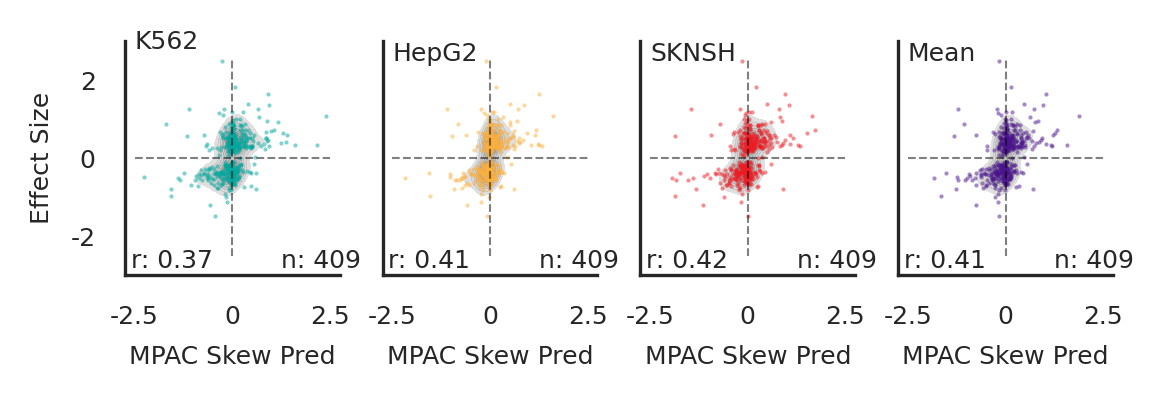

In [74]:
# okay let's plot the standard GTEx comparisons for each cell type
# plot correlations of mpac predictions to parm
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,4)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='k562_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['k562_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='hepg2_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['hepg2_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='sknsh_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='sknsh_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#ED1C24',
                alpha=0.5,)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['sknsh_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='mpac_skew_avg',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='mpac_skew_avg',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.5,)
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['mpac_skew_avg'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()
plt.savefig('MPAC_proAI_eQTL_scatter_all.pdf')

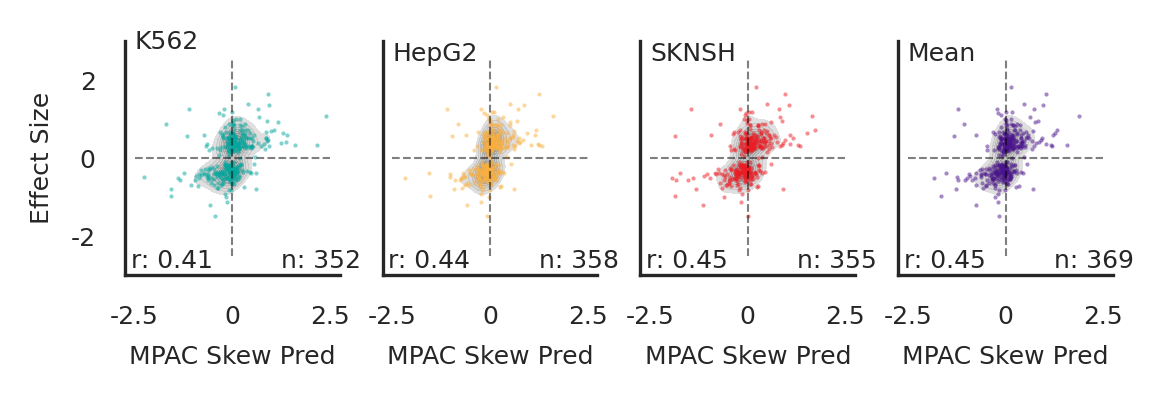

In [75]:
# okay let's plot the standard GTEx comparisons for each cell type
# Active Only #
# plot correlations of mpac predictions to gtex eqtls
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,4)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_active'] == 1],
                x='k562_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_active'] == 1],
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_active'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_active'] == 1]['k562_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_active'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_active'] == 1],
                x='hepg2_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_active'] == 1],
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_active'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_active'] == 1]['hepg2_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_active'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_active'] == 1],
                x='sknsh_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_active'] == 1],
                x='sknsh_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#ED1C24',
                alpha=0.5,)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_active'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_active'] == 1]['sknsh_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_active'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['active_any'] == 1],
                x='mpac_skew_avg',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['active_any'] == 1],
                x='mpac_skew_avg',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.5,)
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['active_any'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['active_any'] == 1]['mpac_skew_avg'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['active_any'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()
plt.savefig('MPAC_proAI_eQTL_scatter_active.pdf')

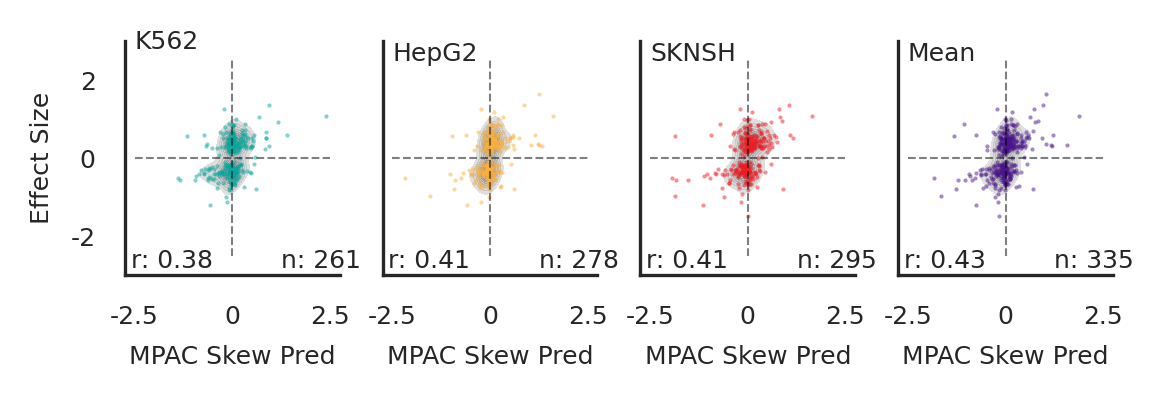

In [77]:
# okay let's plot the standard GTEx comparisons for each cell type
# minimum 1 TPM #
# plot correlations of mpac predictions to gtex eqtls
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,4)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1],
                x='k562_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1],
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1]['k562_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1],
                x='hepg2_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1],
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1]['hepg2_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_rna_tpm'] >= 1],
                x='sknsh_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_rna_tpm'] >= 1],
                x='sknsh_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#ED1C24',
                alpha=0.5,)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_rna_tpm'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_rna_tpm'] >= 1]['sknsh_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_rna_tpm'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1],
                x='mpac_skew_avg',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1],
                x='mpac_skew_avg',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.5,)
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1]['mpac_skew_avg'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()
plt.savefig('MPAC_proAI_eQTL_scatter_min_1tpm.pdf')

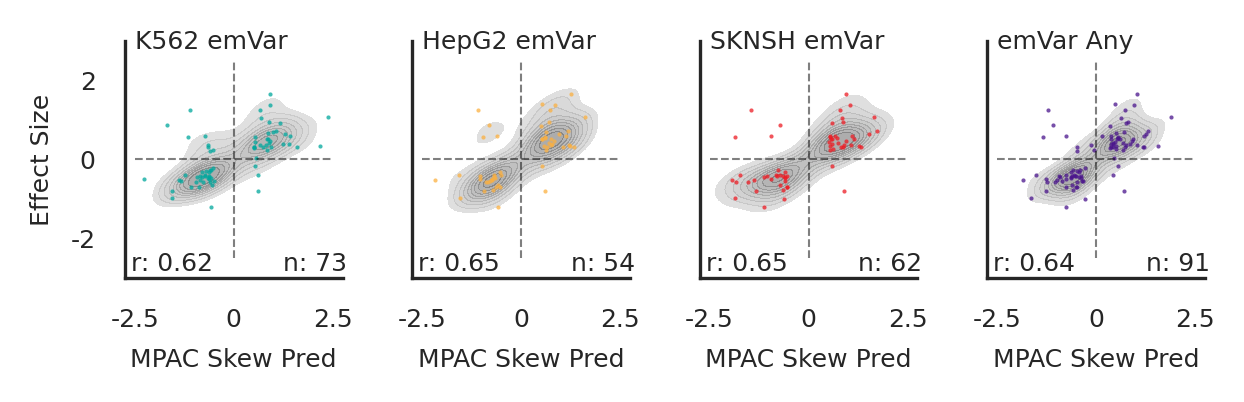

In [82]:
# okay let's plot the emVar comparisons for each cell type
# plot correlations of mpac predictions to parm
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,4)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1],
                x='k562_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1],
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.75)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1]['k562_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562 emVar', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1],
                x='hepg2_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1],
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.75)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1]['hepg2_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2 emVar', xy=(-2.5, 2.8), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1],
                x='sknsh_skew_pred',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1],
                x='sknsh_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#ED1C24',
                alpha=0.75)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1]['sknsh_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH emVar', xy=(-2.5, 2.8), fontsize = 6)
# any #
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1],
                x='mpac_skew_avg',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1],
                x='mpac_skew_avg',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.75)
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1]['sknsh_skew_pred'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('emVar Any', xy=(-2.5, 2.8), fontsize = 6)
plt.tight_layout()
sns.despine()
plt.savefig('MPAC_proAI_eQTL_scatter_emVars.pdf')

In [48]:
mpac_gtex_eqtl_over_under.keys()

Index(['chrom', 'pos', 'id', 'ref', 'alt', 'INFO', 'strand', 'gene',
       'consequence', 'k562_ref_pred', 'hepg2_ref_pred', 'sknsh_ref_pred',
       'k562_alt_pred', 'hepg2_alt_pred', 'sknsh_alt_pred', 'k562_active',
       'hepg2_active', 'sknsh_active', 'active_any', 'k562_skew_pred',
       'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_skew_avg',
       'hepg2_sknsh_avg', 'mpac_skew_max', 'gtex_id', 'stable_id', 'slope',
       'promoterAI_score', 'k562_rna_tpm', 'hepg2_rna_tpm', 'sknsh_rna_tpm',
       'k562_emVar', 'hepg2_emVar', 'sknsh_emVar', 'emVar_any', 'emVar_all',
       'promoterAI_concordant', 'mpac_k562_concordant',
       'mpac_hepg2_concordant', 'mpac_sknsh_concordant', 'mpac_any_concordant',
       'parm_hepg2_skew', 'parm_k562_skew', 'parm_mean_skew',
       'parm_hepg2_emVar', 'parm_k562_emVar', 'parm_emVar_any',
       'parm_hepg2_concordant', 'parm_k562_concordant', 'parm_any_concordant'],
      dtype='object')

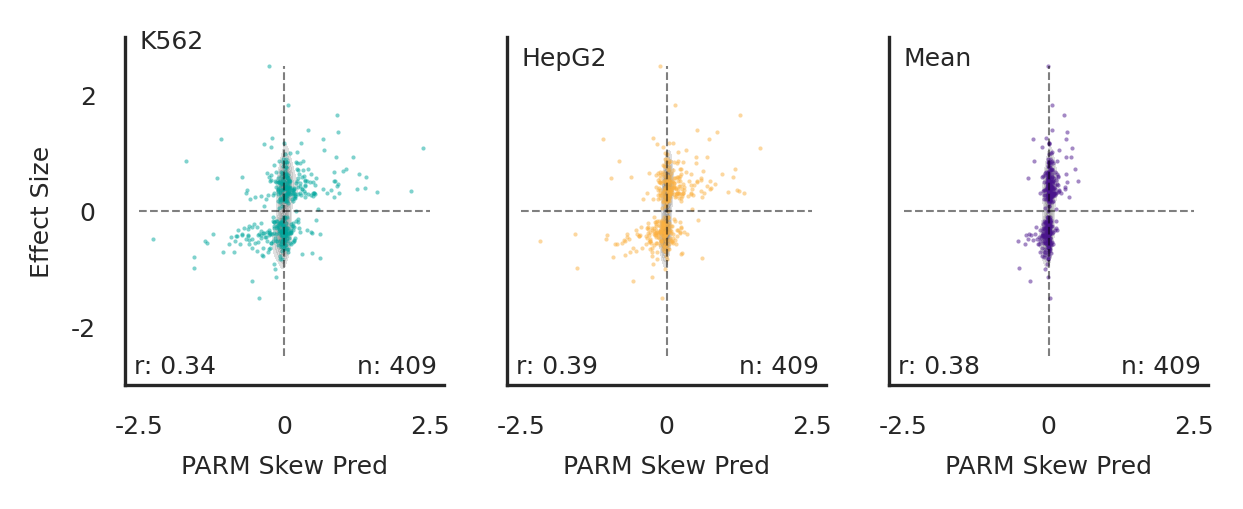

In [86]:
# PARM #
# okay let's plot the standard GTEx comparisons for each cell type
# plot correlations of mpac predictions to parm
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='parm_k562_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['parm_k562_skew'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='parm_hepg2_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['parm_hepg2_skew'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# mean #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under,
                x='parm_mean_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under,
                x='parm_mean_skew',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under['parm_mean_skew'], 
                                            y=mpac_gtex_eqtl_over_under['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
plt.tight_layout()
sns.despine()
plt.savefig('PARM_proAI_eQTL_scatter_all.pdf')

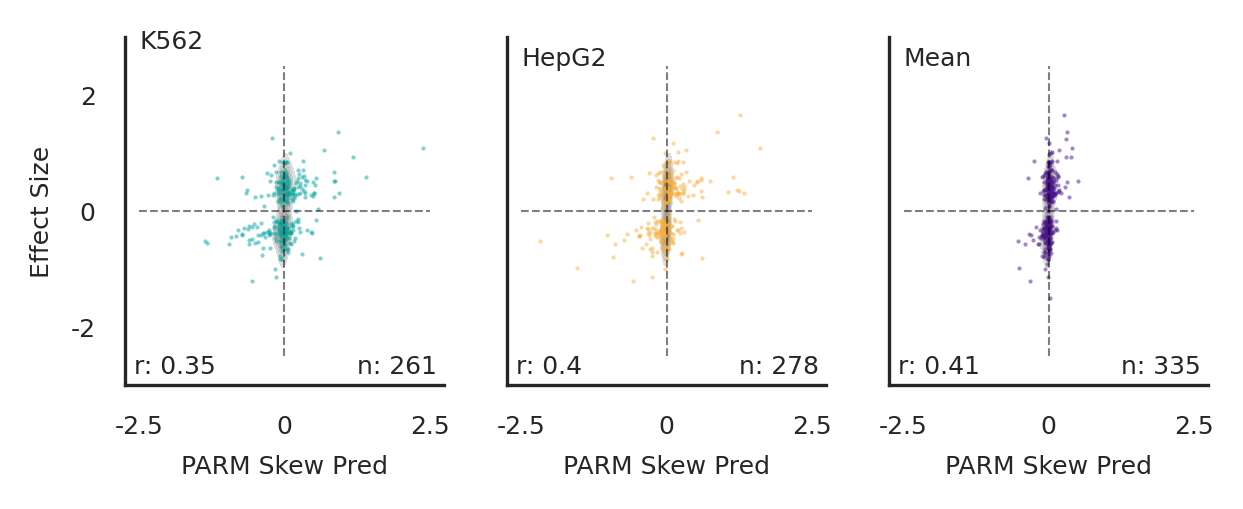

In [103]:
# PARM #
# okay let's plot min 1 TPM correlations
# plot correlations of mpac predictions to parm
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1],
                x='parm_k562_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1],
                x='k562_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1]['parm_k562_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_rna_tpm'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1],
                x='parm_hepg2_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1],
                x='hepg2_skew_pred',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1]['parm_hepg2_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_rna_tpm'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# mean #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1],
                x='parm_mean_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1],
                x='parm_mean_skew',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1]['parm_mean_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['expressed_any'] >= 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
plt.tight_layout()
sns.despine()
plt.savefig('PARM_proAI_eQTL_scatter_min1_tpm.pdf')

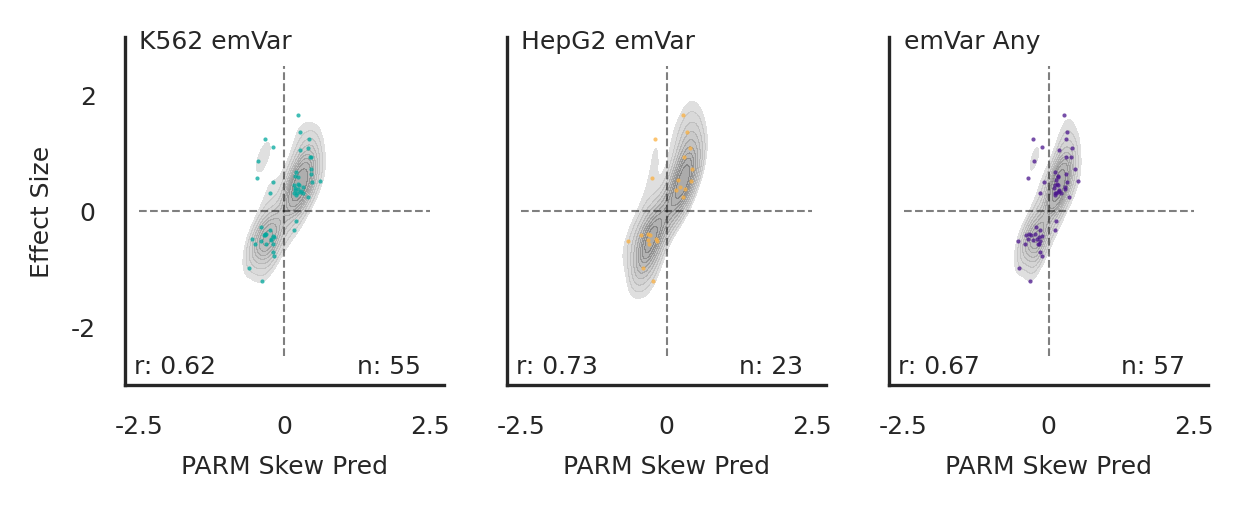

In [104]:
# okay let's plot the emVar comparisons for each cell type
# plot correlations of mpac predictions to parm
f = plt.figure(figsize=(4.25,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_k562_emVar'] == 1],
                x='parm_k562_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_k562_emVar'] == 1],
                x='parm_k562_skew',
                y='slope',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.75)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_k562_emVar'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_k562_emVar'] == 1]['parm_k562_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_k562_emVar'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562 emVar', xy=(-2.5, 2.8), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_hepg2_emVar'] == 1],
                x='parm_hepg2_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_hepg2_emVar'] == 1],
                x='parm_hepg2_skew',
                y='slope',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.75)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_hepg2_emVar'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_hepg2_emVar'] == 1]['parm_hepg2_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_hepg2_emVar'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2 emVar', xy=(-2.5, 2.8), fontsize = 6)
# either #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_emVar_any'] == 1],
                x='parm_mean_skew',
                y='slope',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_emVar_any'] == 1],
                x='parm_mean_skew',
                y='slope',
                linewidth=0,
                s=1,
                color='#4A148C',
                alpha=0.75)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_emVar_any'] == 1])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_emVar_any'] == 1]['parm_mean_skew'], 
                                            y=mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['parm_emVar_any'] == 1]['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('emVar Any', xy=(-2.5, 2.8), fontsize = 6)
plt.tight_layout()
sns.despine()
plt.savefig('PARM_proAI_eQTL_scatter_emVar.pdf')

In [105]:
# summarize some of the discordance
# full set
print('The full eQTL Set')
print(f'There are {sum(mpac_gtex_eqtl_over_under['mpac_k562_concordant'])} concordant MPAC eQTL predictions in K562, {round( (100 * sum(mpac_gtex_eqtl_over_under['mpac_k562_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['mpac_hepg2_concordant'])} concordant MPAC eQTL predictions in HepG2, {round( (100 * sum(mpac_gtex_eqtl_over_under['mpac_hepg2_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['mpac_sknsh_concordant'])} concordant MPAC eQTL predictions in SKNSH, {round( (100 * sum(mpac_gtex_eqtl_over_under['mpac_sknsh_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['mpac_any_concordant'])} concordant MPAC eQTL predictions in any MPAC cell type, {round( (100 * sum(mpac_gtex_eqtl_over_under['mpac_any_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['parm_k562_concordant'])} concordant PARM eQTL predictions in K562, {round( (100 * sum(mpac_gtex_eqtl_over_under['parm_k562_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['parm_hepg2_concordant'])} concordant PARM eQTL predictions in HepG2, {round( (100 * sum(mpac_gtex_eqtl_over_under['parm_hepg2_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under['promoterAI_concordant'])} concordant promoterAI eQTL predictions, {round( (100 * sum(mpac_gtex_eqtl_over_under['promoterAI_concordant']) / len(mpac_gtex_eqtl_over_under)), 2)}%')
# emVars
print('Only MPAC emVars')
print(f'There are {sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1]['mpac_k562_concordant'])} concordant MPAC emVar eQTL predictions in K562, {round( (100 * sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1]['mpac_k562_concordant']) / len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['k562_emVar'] == 1])), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1]['mpac_hepg2_concordant'])} concordant MPAC emVar eQTL predictions in HepG2, {round( (100 * sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1]['mpac_hepg2_concordant']) / len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['hepg2_emVar'] == 1])), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1]['mpac_sknsh_concordant'])} concordant MPAC emVar eQTL predictions in SKNSH, {round( (100 * sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1]['mpac_sknsh_concordant']) / len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['sknsh_emVar'] == 1])), 2)}%')
print(f'There are {sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1]['mpac_any_concordant'])} concordant MPAC emVar eQTL predictions in any MPAC cell type, {round( (100 * sum(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1]['mpac_any_concordant']) / len(mpac_gtex_eqtl_over_under[mpac_gtex_eqtl_over_under['emVar_any'] == 1])), 2)}%')

The full eQTL Set
There are 278 concordant MPAC eQTL predictions in K562, 67.97%
There are 295 concordant MPAC eQTL predictions in HepG2, 72.13%
There are 286 concordant MPAC eQTL predictions in SKNSH, 69.93%
There are 325 concordant MPAC eQTL predictions in any MPAC cell type, 79.46%
There are 270 concordant PARM eQTL predictions in K562, 66.01%
There are 275 concordant PARM eQTL predictions in HepG2, 67.24%
There are 324 concordant promoterAI eQTL predictions, 79.22%
Only MPAC emVars
There are 62 concordant MPAC emVar eQTL predictions in K562, 84.93%
There are 48 concordant MPAC emVar eQTL predictions in HepG2, 88.89%
There are 56 concordant MPAC emVar eQTL predictions in SKNSH, 90.32%
There are 82 concordant MPAC emVar eQTL predictions in any MPAC cell type, 90.11%


In [12]:
# open the gtex caviar variants
gtex_caviar = pd.read_csv('../raw_data/gtex_comparisons/GTEx_Data/GTEx_v8_finemapping_CAVIAR/CAVIAR_Results_v8_GTEx_LD_ALL_NOCUTOFF_with_Allele.txt.gz', sep = '\t')

In [13]:
all_gtex_cat.head()

,variant_id,gene_id,tss_distance,ma_samples,ma_count,maf,pval_nominal,slope,slope_se,pval_nominal_threshold,min_pval_nominal,pval_beta,tissue,pip_filter_id
0,chr1_17005_A_G_b38,ENSG00000227232.5,-12548,17,17,0.017103,3.207170e-04,-0.680903,0.187703,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_17005_A_G_b38_ENSG00000227232.5_Esophagus...
1,chr1_64764_C_T_b38,ENSG00000227232.5,35211,64,65,0.065392,3.300840e-08,0.550227,0.097761,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_64764_C_T_b38_ENSG00000227232.5_Esophagus...
2,chr1_665098_G_A_b38,ENSG00000227232.5,635545,107,113,0.113682,3.392010e-09,0.457540,0.075776,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_665098_G_A_b38_ENSG00000227232.5_Esophagu...
3,chr1_666028_G_A_b38,ENSG00000227232.5,636475,97,103,0.103622,4.867940e-09,0.467178,0.078195,0.000469,3.392010e-09,0.000004,Esophagus_Mucosa,chr1_666028_G_A_b38_ENSG00000227232.5_Esophagu...
4,chr1_126108_G_A_b38,ENSG00000268903.1,-9787,67,67,0.067404,1.070960e-04,-0.424872,0.108648,0.000437,7.214120e-06,0.006632,Esophagus_Mucosa,chr1_126108_G_A_b38_ENSG00000268903.1_Esophagu...


In [14]:
# get the high pip (> 0.9) variants
gtex_high_pip_vars = gtex_caviar[gtex_caviar['Probability'] > 0.9]
gtex_high_pip_vars.loc[:, 'high_pip_filter_id'] = [('_').join([id, gene, tissue]) for id, gene, tissue in zip(gtex_high_pip_vars['eQTL'],
                                                                                                              gtex_high_pip_vars['GENE'],
                                                                                                              gtex_high_pip_vars['TISSUE'])]

/tmp/ipykernel_3605518/1610408131.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtex_high_pip_vars.loc[:, 'high_pip_filter_id'] = [('_').join([id, gene, tissue]) for id, gene, tissue in zip(gtex_high_pip_vars['eQTL'],


In [15]:
gtex_high_pip_vars

,TISSUE,GENE,eQTL,CHROM,POS,Probability,high_pip_filter_id
100,Brain_Caudate_basal_ganglia,ENSG00000162769.12,chr1_212904839_A_T_b38,1,212904839,0.999549,chr1_212904839_A_T_b38_ENSG00000162769.12_Brai...
458,Brain_Caudate_basal_ganglia,ENSG00000259823.5,chr1_248648316_G_A_b38,1,248648316,0.907137,chr1_248648316_G_A_b38_ENSG00000259823.5_Brain...
600,Brain_Caudate_basal_ganglia,ENSG00000273136.6,chr1_120332473_A_G_b38,1,120332473,0.999811,chr1_120332473_A_G_b38_ENSG00000273136.6_Brain...
700,Brain_Caudate_basal_ganglia,ENSG00000134184.12,chr1_109675302_G_A_b38,1,109675302,0.969084,chr1_109675302_G_A_b38_ENSG00000134184.12_Brai...
800,Brain_Caudate_basal_ganglia,ENSG00000215861.5,chr1_149103446_T_A_b38,1,149103446,1.000000,chr1_149103446_T_A_b38_ENSG00000215861.5_Brain...
...,...,...,...,...,...,...,...
22857351,Brain_Amygdala,ENSG00000274602.4,chr22_18531430_G_A_b38,22,18531430,0.999786,chr22_18531430_G_A_b38_ENSG00000274602.4_Brain...
22857352,Brain_Amygdala,ENSG00000274602.4,chr22_18186065_C_T_b38,22,18186065,0.995338,chr22_18186065_C_T_b38_ENSG00000274602.4_Brain...
22857501,Brain_Amygdala,ENSG00000183628.12,chr22_18940813_T_C_b38,22,18940813,0.927247,chr22_18940813_T_C_b38_ENSG00000183628.12_Brai...
22858051,Brain_Amygdala,ENSG00000273253.2,chr22_50200073_T_C_b38,22,50200073,1.000000,chr22_50200073_T_C_b38_ENSG00000273253.2_Brain...


In [16]:
# filter all eQTLs variants for the high pip variants
gtex_high_pip = all_gtex_cat[all_gtex_cat['pip_filter_id'].isin(list(gtex_high_pip_vars['high_pip_filter_id'].tolist()))]

In [17]:
len(gtex_high_pip['variant_id'].unique())

20889

In [40]:
gtex_high_pip.head()

,variant_id,gene_id,tss_distance,ma_samples,ma_count,maf,pval_nominal,slope,slope_se,pval_nominal_threshold,min_pval_nominal,pval_beta,tissue,pip_filter_id
151,chr1_14677_G_A_b38,ENSG00000228327.3,-763949,45,45,0.045272,2.480680e-09,0.655426,0.107575,0.000197,2.480680e-09,1.066300e-05,Esophagus_Mucosa,chr1_14677_G_A_b38_ENSG00000228327.3_Esophagus...
526,chr1_841166_A_G_b38,ENSG00000228794.8,16028,194,223,0.224346,4.352090e-12,0.290774,0.040789,0.000187,4.352090e-12,3.088700e-08,Esophagus_Mucosa,chr1_841166_A_G_b38_ENSG00000228794.8_Esophagu...
685,chr1_906982_C_T_b38,ENSG00000230699.2,-4453,223,243,0.244467,1.449010e-14,-0.506698,0.063566,0.000180,1.449010e-14,1.738860e-10,Esophagus_Mucosa,chr1_906982_C_T_b38_ENSG00000230699.2_Esophagu...
831,chr1_946870_C_A_b38,ENSG00000188976.10,-12439,28,28,0.028169,1.310740e-10,-0.426245,0.064696,0.000188,1.310740e-10,7.512200e-07,Esophagus_Mucosa,chr1_946870_C_A_b38_ENSG00000188976.10_Esophag...
899,chr1_1050658_G_C_b38,ENSG00000188976.10,91349,13,13,0.013458,9.895690e-09,0.549900,0.094030,0.000188,1.310740e-10,7.512200e-07,Esophagus_Mucosa,chr1_1050658_G_C_b38_ENSG00000188976.10_Esopha...


In [18]:
mean_gtex_slope = gtex_high_pip.filter(['variant_id', 'gene_id', 'slope']).groupby(['variant_id', 'gene_id']).mean().reset_index()

In [19]:
mean_gtex_slope.head()

,variant_id,gene_id,slope
0,chr10_100126842_CTAGTTATTTATT_C_b38,ENSG00000232230.1,1.493070
1,chr10_100142018_C_T_b38,ENSG00000095485.16,0.517473
2,chr10_100267779_A_T_b38,ENSG00000095485.16,-0.519996
3,chr10_100277032_G_C_b38,ENSG00000196072.11,-0.849213
4,chr10_100315722_G_A_b38,ENSG00000099194.5,-0.242958


In [20]:
highPIP_gtex_dict = dict(zip(mean_gtex_slope['variant_id'], mean_gtex_slope['slope']))

In [21]:
# add a gtex id to the promoter preds
promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],
                                                                                                                             promoterAI_filtered_preds['pos'],
                                                                                                                             promoterAI_filtered_preds['ref'],
                                                                                                                             promoterAI_filtered_preds['alt'])]

/tmp/ipykernel_3605518/531265095.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],


In [22]:
# filter the full predictions for the high pip gtex variants
highPIP_gtex_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(gtex_high_pip['variant_id'])]

In [23]:
len(highPIP_gtex_preds)

619

In [24]:
# add slope
highPIP_gtex_preds.loc[:, 'slope'] = [highPIP_gtex_dict.get(i) for i in highPIP_gtex_preds['gtex_id']]

/tmp/ipykernel_3605518/2397763827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highPIP_gtex_preds.loc[:, 'slope'] = [highPIP_gtex_dict.get(i) for i in highPIP_gtex_preds['gtex_id']]


In [ ]:
highPIP_gtex_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,parm_hepg2_emVar,parm_emVar_any,mpac_mean_skew,mpac_max_skew,parm_max_skew,var_id,phyloP_470,phyloP_241,gtex_id,slope
10180,chr1,1173872,ENSG00000162571.14_ENST00000379289.6_TTLL10..c...,A,G,0.869550,1.362257,0.492707,1.151818,1.578229,...,0,0,0.355709,0.492707,0.077070,chr1:1173872:A:G,-1.784,-4.588,chr1_1173872_A_G_b38,-0.454956
27388,chr1,1615322,ENSG00000197530.13_ENST00000355826.10_MIB2..ch...,A,G,5.537889,5.568151,0.030263,4.898324,4.924859,...,0,0,0.033796,0.044591,-0.055008,chr1:1615322:A:G,-1.155,-1.153,chr1_1615322_A_G_b38,-0.323534
28812,chr1,1659060,ENSG00000248333.9_ENST00000341832.11_CDK11B..c...,G,A,7.281986,7.275095,-0.006890,4.949587,4.934012,...,0,0,-0.006158,-0.015576,0.064315,chr1:1659060:G:A,-3.057,-1.945,chr1_1659060_G_A_b38,0.885957
34455,chr1,2019112,ENSG00000187730.9_ENST00000378585.7_GABRD..chr...,G,A,2.087069,2.153853,0.066784,1.597651,1.645369,...,0,0,0.072020,0.101557,0.010694,chr1:2019112:G:A,0.202,0.736,chr1_2019112_G_A_b38,0.770491
56824,chr1,6206026,ENSG00000158286.13_ENST00000377939.5_RNF207..c...,A,G,2.990099,2.604843,-0.385257,3.008510,2.751685,...,0,1,-0.366316,-0.456866,-0.309914,chr1:6206026:A:G,-0.506,0.049,chr1_6206026_A_G_b38,-1.133130


Text(0.5, 1.0, 'MPAC K562 | r: 0.29')

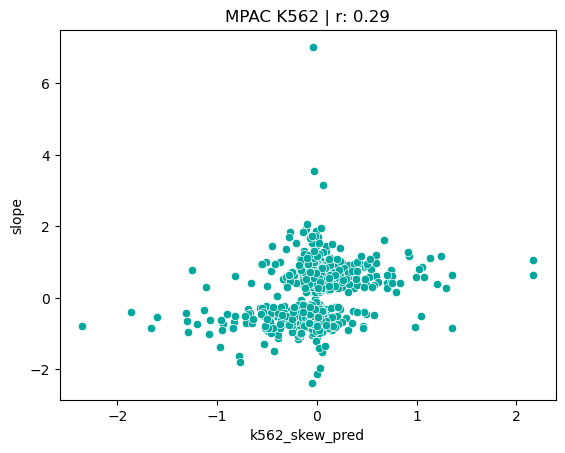

In [25]:
k_mpac_corr = round(stats.pearsonr(x=highPIP_gtex_preds['k562_skew_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'k562_skew_pred',
    y = 'slope',
    color = '#00A79D'
)
plt.title(f'MPAC K562 | r: {k_mpac_corr}')

Text(0.5, 1.0, 'MPAC HepG2 | r: 0.3')

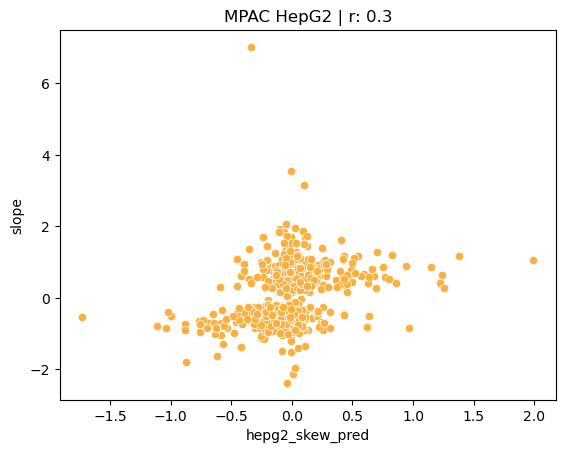

In [26]:
h_mpac_corr = round(stats.pearsonr(x=highPIP_gtex_preds['hepg2_skew_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'hepg2_skew_pred',
    y = 'slope',
    color = '#FBB040'
)
plt.title(f'MPAC HepG2 | r: {h_mpac_corr}')

Text(0.5, 1.0, 'MPAC SKNSH | r: 0.32')

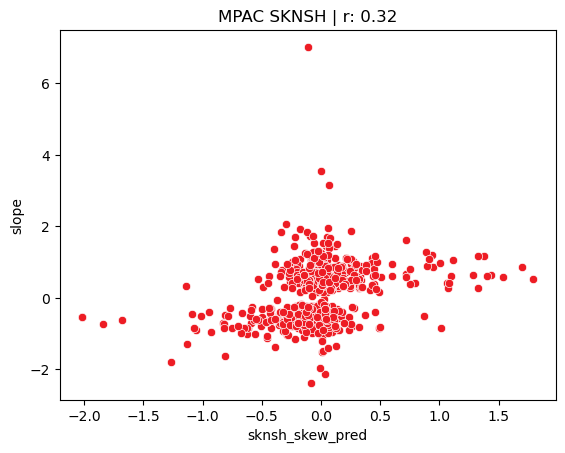

In [27]:
s_mpac_corr = round(stats.pearsonr(x=highPIP_gtex_preds['sknsh_skew_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'sknsh_skew_pred',
    y = 'slope',
    color = '#ED1C24'
)
plt.title(f'MPAC SKNSH | r: {s_mpac_corr}')

Text(0.5, 1.0, 'MPAC Mean | r: 0.31')

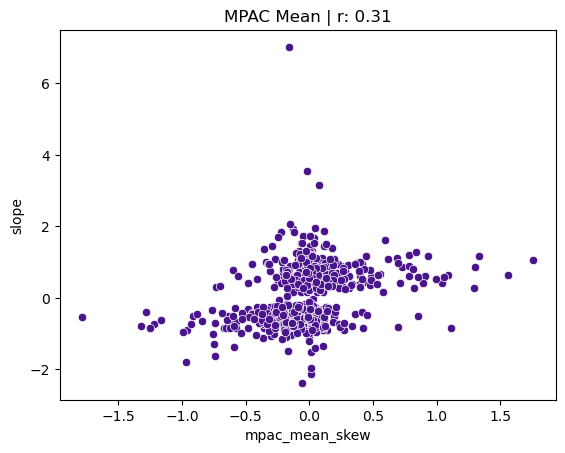

In [30]:
mean_mpac_corr = round(stats.pearsonr(x=highPIP_gtex_preds['mpac_mean_skew'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'mpac_mean_skew',
    y = 'slope',
    color = '#4A148C'
)
plt.title(f'MPAC Mean | r: {mean_mpac_corr}')

Text(0.5, 1.0, 'promoterAI | r: 0.41')

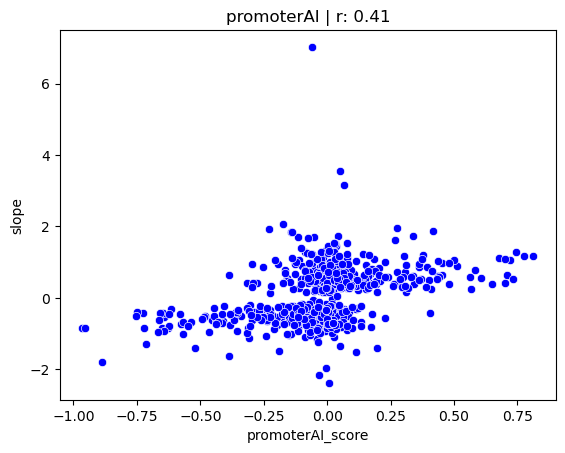

In [33]:
pAI_corr = round(stats.pearsonr(x=highPIP_gtex_preds['promoterAI_score'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'promoterAI_score',
    y = 'slope',
    color = 'blue'
)
plt.title(f'promoterAI | r: {pAI_corr}')

Text(0.5, 1.0, 'PARM K562| r: 0.25')

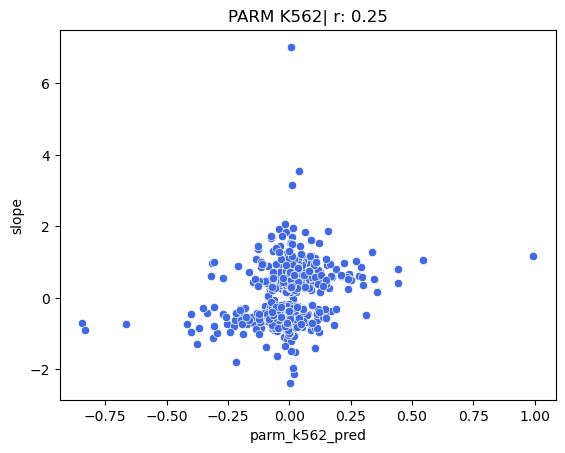

In [34]:
parm_k_corr = round(stats.pearsonr(x=highPIP_gtex_preds['parm_k562_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'parm_k562_pred',
    y = 'slope',
    color = 'royalblue'
)
plt.title(f'PARM K562| r: {parm_k_corr}')

Text(0.5, 1.0, 'PARM HepG2| r: 0.23')

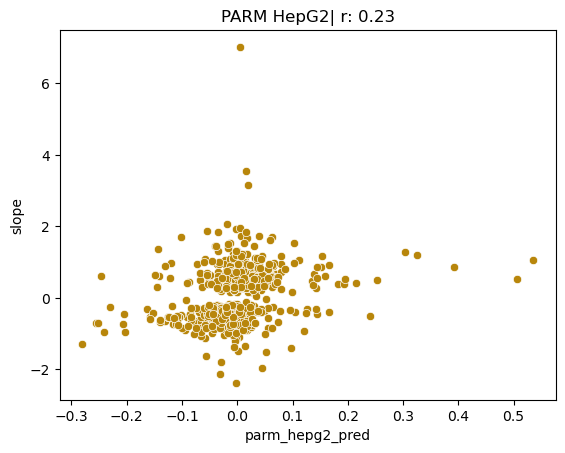

In [36]:
parm_h_corr = round(stats.pearsonr(x=highPIP_gtex_preds['parm_hepg2_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'parm_hepg2_pred',
    y = 'slope',
    color = 'darkgoldenrod'
)
plt.title(f'PARM HepG2| r: {parm_h_corr}')

Text(0.5, 1.0, 'PARM Mean | r: 0.27')

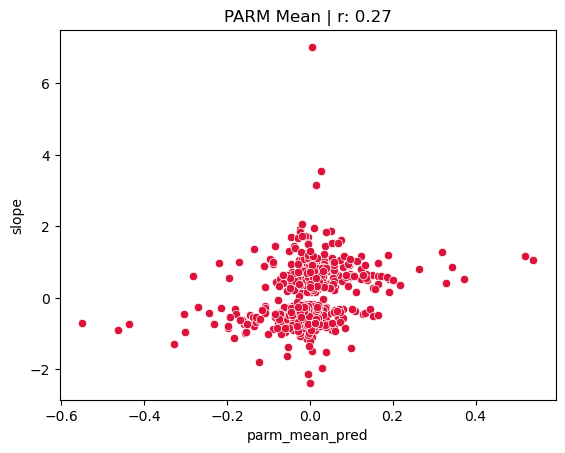

In [39]:
parm_mean_corr = round(stats.pearsonr(x=highPIP_gtex_preds['parm_mean_pred'], y=highPIP_gtex_preds['slope'])[0],2)
sns.scatterplot(
    data = highPIP_gtex_preds,
    x = 'parm_mean_pred',
    y = 'slope',
    color = 'crimson'
)
plt.title(f'PARM Mean | r: {parm_mean_corr}')

In [8]:
# open dnase data for curiosity
k562_dnase = pd.read_csv('../raw_data/dnase_comps/k562_dnase_cav_merged_017_avg.txt', sep = '\t')

In [27]:
stats.pearsonr(x=k562_dnase[k562_dnase['min_fdr'] <= 0.05]['es_weighted_mean'], y=k562_dnase[k562_dnase['min_fdr'] <= 0.05]['k562_skew_pred'])

PearsonRResult(statistic=np.float64(-0.42857544048584073), pvalue=np.float64(6.875758957897258e-58))

In [20]:
k_dnase_dict = dict(zip(k562_dnase['id'], k562_dnase['es_weighted_mean']))

In [17]:
k_dnase_ase_check = promoterAI_filtered_preds[promoterAI_filtered_preds['var_id'].isin(k562_dnase[k562_dnase['min_fdr'] <= 0.05]['id'].tolist())]

In [21]:
k_dnase_ase_check.loc[:, 'k562_dnase_ase'] = [k_dnase_dict.get(i) for i in k_dnase_ase_check['var_id']]

/tmp/ipykernel_3611669/3665376655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  k_dnase_ase_check.loc[:, 'k562_dnase_ase'] = [k_dnase_dict.get(i) for i in k_dnase_ase_check['var_id']]


<Axes: xlabel='k562_dnase_ase', ylabel='k562_skew_pred'>

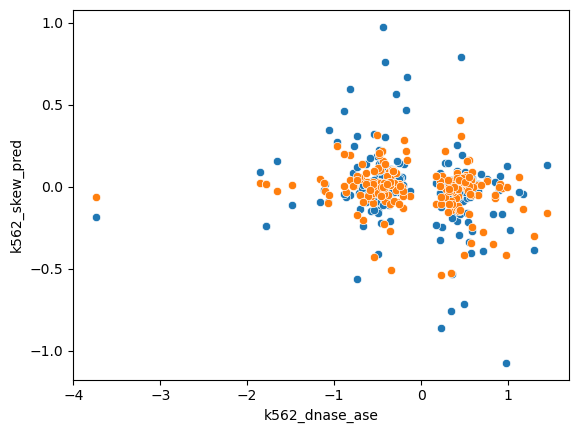

In [23]:
sns.scatterplot(
    data = k_dnase_ase_check,
    x = 'k562_dnase_ase',
    y = 'k562_skew_pred'
)
sns.scatterplot(
    data = k_dnase_ase_check,
    x = 'k562_dnase_ase',
    y = 'promoterAI_score'
)

In [24]:
stats.pearsonr(
    x = k_dnase_ase_check['k562_dnase_ase'],
    y = k_dnase_ase_check['k562_skew_pred']
)

PearsonRResult(statistic=np.float64(-0.17142460200456605), pvalue=np.float64(0.013294690192197232))

In [25]:
stats.pearsonr(
    x = k_dnase_ase_check['k562_dnase_ase'],
    y = k_dnase_ase_check['promoterAI_score']
)

PearsonRResult(statistic=np.float64(-0.16134993001579884), pvalue=np.float64(0.019897518284165163))

In [45]:
# save the dropNA predictions to disk for calling seqlets in 'promoterAI_promoter_filtering_v2.ipynb'
# we will be saving everything but we will only compare those with full 750 bp promoters (we'll save those as TSV from above Counter)
merged_preds_dropNA.to_csv('../processed_data/all.merged.250bp.promoter.preds.pAI.parm.mpac.dropNA.tsv', sep = '\t', index = False)
# save complete promoter IDs for analysis
pd.DataFrame({'promoter_id' : complete_promoters}).to_csv('../processed_data/complete.merged.250bp.promoters.exon.filtered.tsv', sep = '\t', index = False)